# Instructions for Setup

- create a new conda environment
- pip install -r requirements.txt -qq
- Download model using: 
    cd utils && python download_model.py -m Skywork/Skywork-o1-Open-PRM-Qwen-2.5-1.5B --cache_dir_base YOUR_HF_CACHE_DIR
- Update constants/model_constants.py with path of the model
- Run the next few cells once to make load of model faster

In [1]:
import warnings
warnings.filterwarnings('ignore')
# Ignore error traces and warnings

import torch
from transformers import AutoTokenizer

from constants.model_constants import MODEL_CLASS_MAP
from utils.io_utils import prepare_input, derive_step_rewards

In [2]:
# Update this path and the path in constants/model_constants.py as well
path = "/data/atomar/.cache/huggingface/hub"
SKYWORK_MODEL_PATH = f"{path}/Skywork--Skywork-o1-Open-PRM-Qwen-2.5-1.5B"

In [25]:
# import sys
# sys.path.append('/home/rishabhtiwari/prm-inference')

## Run this once to make subsequent loading of model faster

In [26]:
# # Takes around 10 mins to run

# from transformers import AutoModelForCausalLM
# import torch
# # Load the model
# print("Loading model...")
# model = MODEL_CLASS_MAP[SKYWORK_MODEL_PATH].from_pretrained(
#     SKYWORK_MODEL_PATH,
#     torch_dtype=torch.bfloat16,
#     device_map="cpu"  # Keep on CPU for conversion
# )

# # Save with safetensors format
# print("Saving in safetensors format...")
# model.save_pretrained(
#     SKYWORK_MODEL_PATH,
#     safe_serialization=True  # This enables safetensors format
# )

# print("Conversion complete!")

# Helper Functions

In [27]:
def calculate_reward(model_path, problem, steps):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    
    model = MODEL_CLASS_MAP[model_path].from_pretrained(model_path, device_map="auto", torch_dtype=torch.float16)
    model = model.eval()
    input_ids, token_masks = prepare_input(
                            model_path, 
                            problem=problem, 
                            steps=steps, 
                            tokenizer=tokenizer
                        )
    with torch.inference_mode():
        logits = model(input_ids).logits

    rewards = derive_step_rewards(
        model_path, 
        logits, 
        token_masks, 
        tokenizer
    )
    return rewards

### Loading Dataset

In [3]:
from datasets import load_dataset

# Load the AIME 2025 dataset from Hugging Face
aime_2025_dataset = load_dataset("opencompass/AIME2025", "AIME2025-I", split="test")
aime_2025_data = aime_2025_dataset[:]
idx = 1
aime_2025_data['question'][idx], aime_2025_data['answer'][idx]

('On $\\triangle ABC$ points $A,D,E$, and $B$ lie that order on side $\\overline{AB}$ with $AD=4, DE=16$, and $EB=8$. Points $A,F,G$, and $C$ lie in that order on side $\\overline{AC}$ with $AF=13, FG=52$, and $GC=26$. Let $M$ be the reflection of $D$ through $F$, and let $N$ be the reflection of $G$ through $E$. Quadrilateral $DEGF$ has area 288. Find the area of heptagon $AFNBCEM$.',
 '588')

In [4]:


data = {
    # "problem": "Cindy's math and science books weigh 2 pounds each. Her French book weighs 4 pounds and her English book weighs 3 pounds. Her history book weighs twice as much as her English book. If Cindy carries all of her books at once, what will be the total weight of the books she is carrying?",
    "problem": "On $\\triangle ABC$ points $A,D,E$, and $B$ lie that order on side $\\overline{AB}$ with $AD=4, DE=16$, and $EB=8$. Points $A,F,G$, and $C$ lie in that order on side $\\overline{AC}$ with $AF=13, FG=52$, and $GC=26$. Let $M$ be the reflection of $D$ through $F$, and let $N$ be the reflection of $G$ through $E$. Quadrilateral $DEGF$ has area 288. Find the area of heptagon $AFNBCEM$.",
    "steps": [
        # "Some Random Steps",
        "To determine the total weight of all Cindy's books, we need to calculate the weight of each book individually and then sum these weights.", 
        "First, for the math and science books:\n- Each math book weighs 2 pounds.\n- Each science book weighs 2 pounds.\n- Cindy has 2 math books and 2 science books.\n- Total weight of math books: \\(2 \\text{ books} \\times 2 \\text{ pounds/book} = 4 \\text{ pounds}\\).\n- Total weight of science books: \\(2 \\text{ books} \\times 2 \\text{ pounds/book} = 4 \\text{ pounds}\\).\n- Combined weight of math and science books: \\(4 \\text{ pounds} + 4 \\text{ pounds} = 8 \\text{ pounds}\\).", 
        "Second, for the French book:\n- The French book weighs 4 pounds.",
        "Third, for the English book:\n- The English book weighs 3 pounds.", 
        "Fourth, for the history book:\n- The history book weighs twice as much as the English book.\n- Weight of the history book: \\(2 \\times 3 \\text{ pounds} = 6 \\text{ pounds}\\).",
        "Finally, for the total weight:\n- Sum of the weights of all the books: \\[ 8 \\text{ pounds} \\text{ (math and science)} + 4 \\text{ pounds} \\text{ (French)} + 3 \\text{ pounds} \\text{ (English)} + 6 \\text{ pounds} \\text{ (history)} = 21 \\text{ pounds} \\]",
        "Therefore, the total weight of the books Cindy is carrying is \\(\\boxed{21}\\) pounds."
    ],
    "answer": "588"

}

# data = {
#     "problem": aime_2025_data['question'][idx],
#     "answer": aime_2025_data['answer'][idx]
# }
# data["problem"], data["answer"]

In [5]:
tokenizer = AutoTokenizer.from_pretrained(SKYWORK_MODEL_PATH)
    
model = MODEL_CLASS_MAP[SKYWORK_MODEL_PATH].from_pretrained(
    SKYWORK_MODEL_PATH, 
    torch_dtype=torch.bfloat16,
    device_map="cuda:0"
)
print('done')
model = model.eval()
input_ids, token_masks = prepare_input(
                        SKYWORK_MODEL_PATH, 
                        problem=data["problem"], 
                        steps=data["steps"], 
                        tokenizer=tokenizer,
                        device=torch.device("cuda:0")
                    )


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.21it/s]
Some weights of the model checkpoint at /data/atomar/.cache/huggingface/hub/Skywork--Skywork-o1-Open-PRM-Qwen-2.5-1.5B were not used when initializing Qwen2ForCausalLM: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing Qwen2ForCausalLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Qwen2ForCausalLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


done


In [6]:
with torch.inference_mode():
    logits = model(input_ids.view(1, -1))[-1]

rewards = derive_step_rewards(
    SKYWORK_MODEL_PATH, 
    logits, 
    token_masks, 
    tokenizer
)
print(rewards)
# Rewards should be close to: [[0.04739352688193321, 0.04780266061425209, 0.07665631175041199, 0.09360786527395248, 0.08396022021770477, 0.06767538189888, 0.07616749405860901]]

[[0.047110285609960556, 0.04746731370687485, 0.07581236958503723, 0.09235277026891708, 0.08312414586544037, 0.06657344102859497, 0.07574976980686188]]


# Generating Solution Trajectories from Qwen2.5 Math PRM

### Generations are already saved in generated_answers.pkl, uncomment to generate again otherwise skip

In [7]:
from vllm import LLM, SamplingParams

# Load Qwen2.5-Math-7B model using vLLM
llm = LLM(
    model="Qwen/Qwen2.5-Math-7B-Instruct",
    tensor_parallel_size=1,
    gpu_memory_utilization=0.9,
    trust_remote_code=True,
    device="cuda:1"
)



2025-12-08 22:47:52,365	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 12-08 22:47:53 __init__.py:207] Automatically detected platform cuda.
INFO 12-08 22:48:00 config.py:549] This model supports multiple tasks: {'reward', 'classify', 'generate', 'score', 'embed'}. Defaulting to 'generate'.
INFO 12-08 22:48:00 llm_engine.py:234] Initializing a V0 LLM engine (v0.7.3) with config: model='Qwen/Qwen2.5-Math-7B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda:1, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_mod

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:03<00:09,  3.06s/it]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:05<00:05,  2.97s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:07<00:02,  2.28s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:09<00:00,  2.23s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:09<00:00,  2.40s/it]



INFO 12-08 22:48:12 model_runner.py:1115] Loading model weights took 14.2419 GB
INFO 12-08 22:48:13 worker.py:267] Memory profiling takes 0.36 seconds
INFO 12-08 22:48:13 worker.py:267] the current vLLM instance can use total_gpu_memory (79.33GiB) x gpu_memory_utilization (0.90) = 71.39GiB
INFO 12-08 22:48:13 worker.py:267] model weights take 14.24GiB; non_torch_memory takes 0.15GiB; PyTorch activation peak memory takes 1.44GiB; the rest of the memory reserved for KV Cache is 55.56GiB.
INFO 12-08 22:48:13 executor_base.py:111] # cuda blocks: 65022, # CPU blocks: 4681
INFO 12-08 22:48:13 executor_base.py:116] Maximum concurrency for 4096 tokens per request: 253.99x
INFO 12-08 22:48:15 model_runner.py:1434] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI. If out-of-memory error occurs during cudagraph capture, consider decreasing `gpu_memory

Capturing CUDA graph shapes: 100%|██████████| 35/35 [00:10<00:00,  3.25it/s]

INFO 12-08 22:48:26 model_runner.py:1562] Graph capturing finished in 11 secs, took 0.85 GiB
INFO 12-08 22:48:26 llm_engine.py:436] init engine (profile, create kv cache, warmup model) took 13.74 seconds


In [37]:
# Set up sampling parameters for generation
sampling_params = SamplingParams(
    temperature=0.6,
    top_p=0.95,
    max_tokens=2048,
    n=100  # Generate 100 answers
)

# Format the problem as a prompt with step-by-step instructions
prompt = f"""Problem: {data['problem']}

Please solve this problem step by step. Separate each step with a blank line (\\n\\n). Provide your final answer in \\boxed{{}}.

Solution:"""

# Generate 100 answers
outputs = llm.generate([prompt], sampling_params)

# Extract the generated texts
generated_answers = [output.text for output in outputs[0].outputs]


Processed prompts:   0%|          | 0/100 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   1%|          | 1/100 [00:26<43:45, 26.52s/it, est. speed input: 6.56 toks/s, output: 5256.42 toks/s]


In [8]:
import pickle

# Define a filename for saving the generated answers
output_filename = "generated_answers.pkl"

# # Save the generated answers
# with open(output_filename, "wb") as f:
#     pickle.dump(generated_answers, f)
# print(f"Generated answers saved to {output_filename}")

# Load the generated answers back (for verification or later use)
with open(output_filename, "rb") as f:
    loaded_answers = pickle.load(f)
print(f"Loaded {len(loaded_answers)} answers from {output_filename}")

generated_answers = loaded_answers

print(f"Generated {len(generated_answers)} answers")
for i, answer in enumerate(generated_answers[:3]):  # Print first 3 as examples
    print(f"\n--- Answer {i+1} ---")
    print(answer)


Loaded 100 answers from generated_answers.pkl
Generated 100 answers

--- Answer 1 ---
 We start by analyzing the given information and the properties of the reflections and areas.

First, we note that the coordinates of the points on side \(AB\) and \(AC\) can be set up as follows:
- \(A = (0, 0)\)
- \(D = (4, 0)\)
- \(E = (20, 0)\)
- \(B = (24, 0)\)
- \(A = (0, 0)\)
- \(F = (13, 0)\)
- \(G = (65, 0)\)
- \(C = (91, 0)\)

Next, we find the coordinates of the reflections:
- \(M\) is the reflection of \(D\) through \(F\). The midpoint of \(DF\) is \(\left(\frac{4+13}{2}, 0\right) = (8.5, 0)\). Therefore, the coordinates of \(M\) are \((2 \cdot 8.5 - 4, 0) = (13, 0)\).
- \(N\) is the reflection of \(G\) through \(E\). The midpoint of \(GE\) is \(\left(\frac{65+20}{2}, 0\right) = (42.5, 0)\). Therefore, the coordinates of \(N\) are \((2 \cdot 42.5 - 65, 0) = (15, 0)\).

Now, we need to find the area of quadrilateral \(DEGF\). The area of a quadrilateral with vertices \((x_1, y_1)\), \((x_2,

In [9]:
import re

def extract_boxed_answer(text):
    """Extract the answer from \\boxed{} notation"""
    match = re.search(r'\\boxed\{([^}]+)\}', text)
    if match:
        return match.group(1).strip()
    return None

def normalize_answer(answer):
    """Normalize answer for comparison"""
    if answer is None:
        return None
    # Remove spaces and convert to lowercase
    answer = answer.replace(' ', '').lower()
    # Remove common formatting
    answer = answer.replace(',', '')
    return answer

# Extract ground truth answer
ground_truth = data['answer']#extract_boxed_answer(data['answer'])
ground_truth_normalized = normalize_answer(ground_truth)

print(f"Ground truth answer: {ground_truth}")

# Extract predicted answers and check correctness
predicted_answers = []
correctness = []

for i, answer in enumerate(generated_answers):
    predicted = extract_boxed_answer(answer)
    predicted_normalized = normalize_answer(predicted)
    
    is_correct = 1 if predicted_normalized == ground_truth_normalized else 0
    
    predicted_answers.append(predicted)
    correctness.append(is_correct)
    
    # print(f"Answer {i+1}: {predicted} -> {'Correct' if is_correct else 'Incorrect'}")

print(f"\nCorrectness list: {correctness}")
print(f"Accuracy: {sum(correctness)}/{len(correctness)} = {sum(correctness)/len(correctness):.2%}")


Ground truth answer: 588

Correctness list: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Accuracy: 0/100 = 0.00%


In [10]:
def parse_steps_from_generation(text):
    """
    Parse a generated text into individual steps.
    Steps are separated by double newlines (\\n\\n).
    """
    # Split by double newlines to get steps
    steps = [step.strip() for step in text.split('\n\n') if step.strip()]
    return steps

# Parse all generated answers into steps
parsed_generations = []
for i, answer in enumerate(generated_answers):
    steps = parse_steps_from_generation(answer)
    parsed_generations.append(steps)
    print(f"\nGeneration {i+1} has {len(steps)} steps")
    for j, step in enumerate(steps[:3]):  # Print first 3 steps as example
        print(f"  Step {j+1}: {step[:100]}...")  # Print first 100 chars



Generation 1 has 11 steps
  Step 1: We start by analyzing the given information and the properties of the reflections and areas....
  Step 2: First, we note that the coordinates of the points on side \(AB\) and \(AC\) can be set up as follows...
  Step 3: Next, we find the coordinates of the reflections:
- \(M\) is the reflection of \(D\) through \(F\). ...

Generation 2 has 19 steps
  Step 1: To solve the problem, we need to find the area of heptagon \(AFNBCEM\) given the area of quadrilater...
  Step 2: First, let's determine the coordinates of the points on \(AB\) and \(AC\). Assume \(A\) is at \((0,0...
  Step 3: The coordinates of \(D\), \(E\), \(F\), and \(G\) are:
\[ D = (4,0), \quad E = (20,0), \quad F = (15...

Generation 3 has 12 steps
  Step 1: To find the area of heptagon \(AFNBCEM\), we start by analyzing the given information and the proper...
  Step 2: First, we note the coordinates of the points on the triangle \(ABC\). Let \(A = (0,0)\), \(B = (28,0...
  Step 3: Next,

In [11]:
def calculate_stepwise_rewards_for_trajectory(model, tokenizer, problem, steps, model_path, device):
    """
    Calculate step-wise rewards for a single trajectory.
    Returns a list of rewards for each step.
    """
    if len(steps) == 0:
        return []
    
    # Prepare input for the PRM
    input_ids, token_masks = prepare_input(
        model_path, 
        problem=problem, 
        steps=steps, 
        tokenizer=tokenizer,
        device=device
    )
    
    # Get logits from model
    with torch.inference_mode():
        logits = model(input_ids.view(1, -1))[-1]
    
    # Derive step rewards
    rewards = derive_step_rewards(
        model_path, 
        logits, 
        token_masks, 
        tokenizer
    )
    
    # rewards is a list with one element (batch of 1), extract it
    return rewards[0] if rewards else []

# Calculate step-wise rewards for all generations
all_trajectory_rewards = []

for i, steps in enumerate(parsed_generations):
    print(f"\nProcessing generation {i+1}/{len(parsed_generations)}...")
    try:
        rewards = calculate_stepwise_rewards_for_trajectory(
            model=model,
            tokenizer=tokenizer,
            problem=data["problem"],
            steps=steps,
            model_path=SKYWORK_MODEL_PATH,
            device=torch.device("cuda:0")
        )
        all_trajectory_rewards.append(rewards)
        print(f"  Got {len(rewards)} rewards: {[f'{r:.4f}' for r in rewards]}")
    except Exception as e:
        print(f"  Error processing generation {i+1}: {e}")
        all_trajectory_rewards.append([])

print(f"\n\nProcessed {len(all_trajectory_rewards)} trajectories")



Processing generation 1/100...
  Got 11 rewards: ['0.0223', '0.0277', '0.0229', '0.0323', '0.0340', '0.0434', '0.0407', '0.0594', '0.0963', '0.0626', '0.0315']

Processing generation 2/100...
  Got 19 rewards: ['0.0323', '0.0173', '0.0183', '0.0295', '0.0233', '0.0274', '0.0192', '0.0275', '0.0289', '0.0337', '0.0418', '0.0555', '0.0556', '0.0559', '0.0535', '0.0585', '0.0564', '0.1853', '0.2587']

Processing generation 3/100...
  Got 12 rewards: ['0.0382', '0.0386', '0.0471', '0.0421', '0.0360', '0.0446', '0.0437', '0.0421', '0.0437', '0.0460', '0.1158', '0.3773']

Processing generation 4/100...
  Got 10 rewards: ['0.0353', '0.0366', '0.0383', '0.0429', '0.0633', '0.0613', '0.0747', '0.0862', '0.3525', '0.6095']

Processing generation 5/100...
  Got 15 rewards: ['0.0392', '0.0214', '0.0348', '0.0298', '0.0256', '0.0292', '0.0378', '0.0236', '0.0455', '0.0199', '0.0503', '0.0535', '0.0613', '0.3705', '0.4049']

Processing generation 6/100...
  Got 20 rewards: ['0.0372', '0.0489', '0.0

In [12]:
import numpy as np

# Calculate average reward for each trajectory
trajectory_avg_rewards = []

print("Average Rewards per Trajectory:")
print("-" * 60)

for i, rewards in enumerate(all_trajectory_rewards):
    if len(rewards) > 0:
        avg_reward = np.mean(rewards)
        trajectory_avg_rewards.append(avg_reward)
        print(f"Generation {i+1}: {avg_reward:.4f} (from {len(rewards)} steps)")
        print(f"  Step-wise rewards: {[f'{r:.4f}' for r in rewards]}")
    else:
        trajectory_avg_rewards.append(None)
        print(f"Generation {i+1}: No rewards calculated")
    print()

# Summary statistics
valid_rewards = [r for r in trajectory_avg_rewards if r is not None]
if valid_rewards:
    print("-" * 60)
    print("Summary Statistics:")
    print(f"  Number of trajectories: {len(trajectory_avg_rewards)}")
    print(f"  Valid trajectories: {len(valid_rewards)}")
    print(f"  Mean of average rewards: {np.mean(valid_rewards):.4f}")
    print(f"  Std of average rewards: {np.std(valid_rewards):.4f}")
    print(f"  Min average reward: {np.min(valid_rewards):.4f}")
    print(f"  Max average reward: {np.max(valid_rewards):.4f}")


Average Rewards per Trajectory:
------------------------------------------------------------
Generation 1: 0.0430 (from 11 steps)
  Step-wise rewards: ['0.0223', '0.0277', '0.0229', '0.0323', '0.0340', '0.0434', '0.0407', '0.0594', '0.0963', '0.0626', '0.0315']

Generation 2: 0.0568 (from 19 steps)
  Step-wise rewards: ['0.0323', '0.0173', '0.0183', '0.0295', '0.0233', '0.0274', '0.0192', '0.0275', '0.0289', '0.0337', '0.0418', '0.0555', '0.0556', '0.0559', '0.0535', '0.0585', '0.0564', '0.1853', '0.2587']

Generation 3: 0.0763 (from 12 steps)
  Step-wise rewards: ['0.0382', '0.0386', '0.0471', '0.0421', '0.0360', '0.0446', '0.0437', '0.0421', '0.0437', '0.0460', '0.1158', '0.3773']

Generation 4: 0.1401 (from 10 steps)
  Step-wise rewards: ['0.0353', '0.0366', '0.0383', '0.0429', '0.0633', '0.0613', '0.0747', '0.0862', '0.3525', '0.6095']

Generation 5: 0.0832 (from 15 steps)
  Step-wise rewards: ['0.0392', '0.0214', '0.0348', '0.0298', '0.0256', '0.0292', '0.0378', '0.0236', '0.0455'

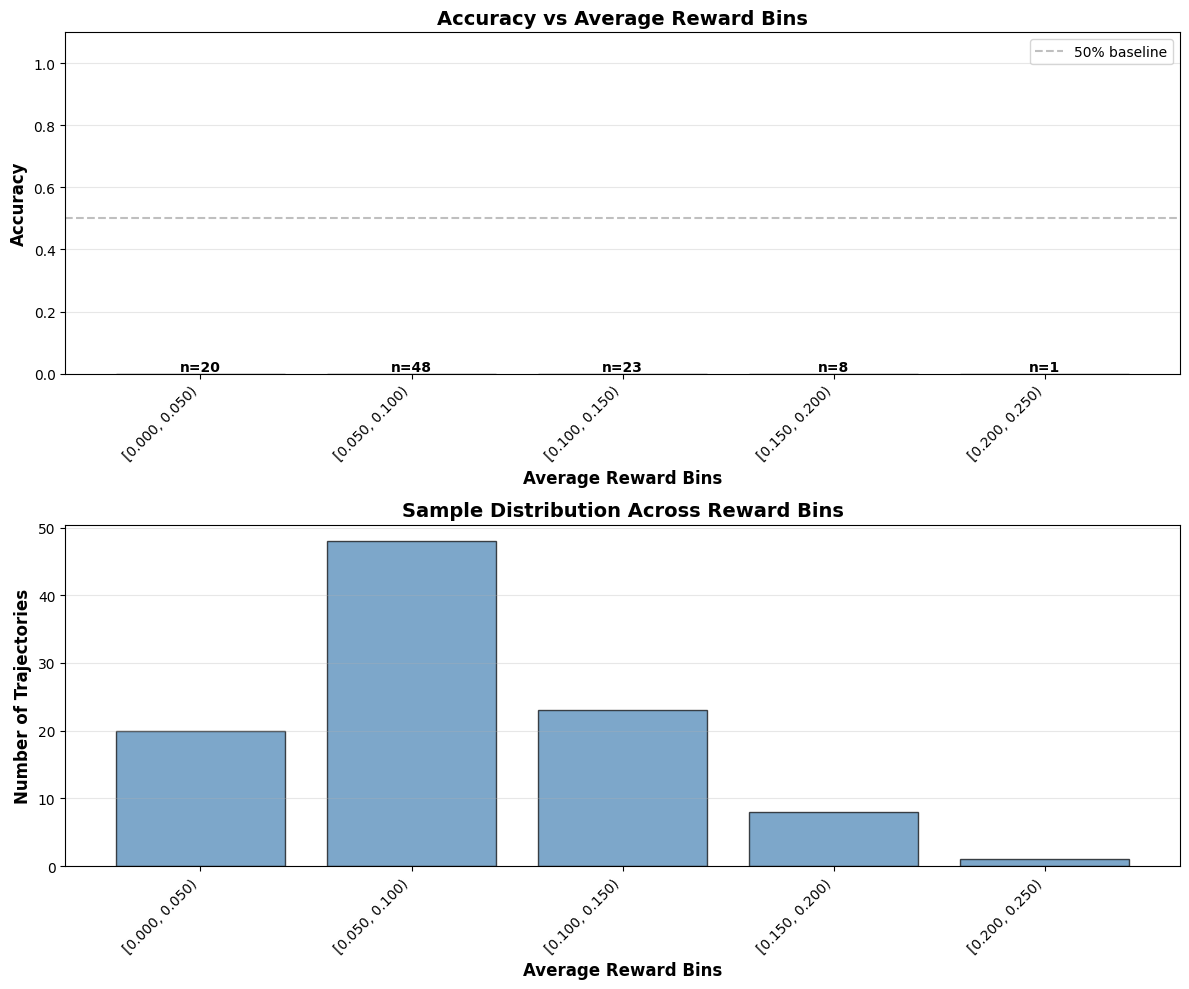


Detailed Bin Statistics:

Bin 1: [0.0000, 0.0500)
  Count: 20
  Accuracy: 0.00%
  Correct: 0/20

Bin 2: [0.0500, 0.1000)
  Count: 48
  Accuracy: 0.00%
  Correct: 0/48

Bin 3: [0.1000, 0.1500)
  Count: 23
  Accuracy: 0.00%
  Correct: 0/23

Bin 4: [0.1500, 0.2000)
  Count: 8
  Accuracy: 0.00%
  Correct: 0/8

Bin 5: [0.2000, 0.2500)
  Count: 1
  Accuracy: 0.00%
  Correct: 0/1


In [13]:
import matplotlib.pyplot as plt

# Prepare data: filter out trajectories with None rewards
valid_data = [(trajectory_avg_rewards[i], correctness[i]) 
              for i in range(len(trajectory_avg_rewards)) 
              if trajectory_avg_rewards[i] is not None]

if len(valid_data) == 0:
    print("No valid data to plot")
else:
    rewards, correct_labels = zip(*valid_data)
    rewards = np.array(rewards)
    correct_labels = np.array(correct_labels)
    
    # Create bins for average rewards with fixed 0.05 intervals
    bin_width = 0.05
    min_reward = np.floor(rewards.min() / bin_width) * bin_width
    max_reward = np.ceil(rewards.max() / bin_width) * bin_width
    bin_edges = np.arange(min_reward, max_reward + bin_width, bin_width)
    n_bins = len(bin_edges) - 1
    
    # Calculate accuracy for each bin
    bin_accuracies = []
    bin_counts = []
    bin_centers = []
    
    for i in range(n_bins):
        # Find trajectories in this bin
        if i == n_bins - 1:
            # Last bin includes the upper edge
            mask = (rewards >= bin_edges[i]) & (rewards <= bin_edges[i+1])
        else:
            mask = (rewards >= bin_edges[i]) & (rewards < bin_edges[i+1])
        
        bin_correct = correct_labels[mask]
        
        if len(bin_correct) > 0:
            accuracy = bin_correct.mean()
            bin_accuracies.append(accuracy)
            bin_counts.append(len(bin_correct))
            bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
        else:
            bin_accuracies.append(0)
            bin_counts.append(0)
            bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
    
    # Create the plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Accuracy vs Average Reward Bins
    colors = ['red' if acc < 0.5 else 'orange' if acc < 0.75 else 'green' 
              for acc in bin_accuracies]
    bars = ax1.bar(range(n_bins), bin_accuracies, color=colors, alpha=0.7, edgecolor='black')
    
    # Add count labels on bars
    for i, (bar, count) in enumerate(zip(bars, bin_counts)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'n={count}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax1.set_xlabel('Average Reward Bins', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Accuracy vs Average Reward Bins', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(n_bins))
    ax1.set_xticklabels([f'[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})' 
                         for i in range(n_bins)], rotation=45, ha='right')
    ax1.set_ylim([0, 1.1])
    ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
    ax1.grid(axis='y', alpha=0.3)
    ax1.legend()
    
    # Plot 2: Sample count per bin
    ax2.bar(range(n_bins), bin_counts, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Average Reward Bins', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Trajectories', fontsize=12, fontweight='bold')
    ax2.set_title('Sample Distribution Across Reward Bins', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(n_bins))
    ax2.set_xticklabels([f'[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})' 
                         for i in range(n_bins)], rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\nDetailed Bin Statistics:")
    print("=" * 80)
    for i in range(n_bins):
        print(f"\nBin {i+1}: [{bin_edges[i]:.4f}, {bin_edges[i+1]:.4f})")
        print(f"  Count: {bin_counts[i]}")
        print(f"  Accuracy: {bin_accuracies[i]:.2%}")
        if bin_counts[i] > 0:
            print(f"  Correct: {int(bin_accuracies[i] * bin_counts[i])}/{bin_counts[i]}")


In [14]:
# Find the trajectory with second minimum average reward
valid_indices = [i for i, r in enumerate(trajectory_avg_rewards) if r is not None]
# Sort valid indices by average reward
sorted_indices = sorted(valid_indices, key=lambda i: trajectory_avg_rewards[i])
if len(sorted_indices) < 2:
    print("Not enough valid trajectories to find the second minimum.")
else:
    min_reward_idx = sorted_indices[30]

    min_reward_value = trajectory_avg_rewards[min_reward_idx]
    min_reward_steps = parsed_generations[min_reward_idx]
    min_reward_answer = predicted_answers[min_reward_idx]

    print(f"Second Minimum Reward Trajectory:")
    print(f"  Index: {min_reward_idx + 1}")
    print(f"  Average Reward: {min_reward_value:.4f}")
    print(f"  Number of Steps: {len(min_reward_steps)}")
    print(f"  Predicted Answer: {min_reward_answer}")
    print(f"  Correct: {'✓' if correctness[min_reward_idx] else '✗'}")
    print(f"\nSteps:")
    for i, step in enumerate(min_reward_steps):
        print(f"  Step {i+1}: {step[:1000]}...")
    print(f"\nStep-wise rewards: {[f'{r:.4f}' for r in all_trajectory_rewards[min_reward_idx]]}")


Second Minimum Reward Trajectory:
  Index: 65
  Average Reward: 0.0610
  Number of Steps: 10
  Predicted Answer: 576
  Correct: ✗

Steps:
  Step 1: Given the points \( A, D, E, B \) on side \( \overline{AB} \) with \( AD = 4 \), \( DE = 16 \), and \( EB = 8 \), the total length of \( AB \) is:
\[ AB = AD + DE + EB = 4 + 16 + 8 = 28. \]...
  Step 2: Similarly, given the points \( A, F, G, C \) on side \( \overline{AC} \) with \( AF = 13 \), \( FG = 52 \), and \( GC = 26 \), the total length of \( AC \) is:
\[ AC = AF + FG + GC = 13 + 52 + 26 = 91. \]...
  Step 3: Let \( D' \) be the reflection of \( D \) through \( F \). Since \( F \) is the midpoint of \( \overline{DF'} \), we have:
\[ DF' = 2 \cdot DF. \]
Since \( D \) is 4 units from \( A \) and \( F \) is 13 units from \( A \), the distance \( DF \) is:
\[ DF = F - D = 13 - 4 = 9. \]
Therefore, the distance \( DF' \) is:
\[ DF' = 2 \cdot 9 = 18. \]
This means that \( D' \) is 18 units to the right of \( F \), so it is \( 13 + 18 = 3

# Optimization to find continuous reward hacked token [no need to run already saved]

In [39]:
import torch.nn.functional as F

def optimize_tokens_for_max_reward(
    model, 
    continuous_optimization,
    tokenizer, 
    problem, 
    steps, 
    model_path, 
    device,
    num_new_tokens=1,
    num_iterations=100,
    learning_rate=0.1,
    temperature=1.0,
    entropy_weight_start=0.001,
    entropy_weight_end=0.1,
    entropy_schedule='linear',
):
    """
    Add random tokens at the end and optimize them to maximize reward.
    
    Args:
        model: The PRM model
        tokenizer: Tokenizer
        problem: Problem statement
        steps: List of reasoning steps
        model_path: Path to model for prepare_input
        device: Device to run on
        num_new_tokens: Number of tokens to add and optimize
        num_iterations: Number of optimization steps
        learning_rate: Learning rate for optimization
        temperature: Temperature for Gumbel-Softmax
        entropy_weight_start: Starting weight for entropy loss
        entropy_weight_end: Ending weight for entropy loss
        entropy_schedule: Schedule type ('linear', 'exponential', 'cosine')
    
    Returns:
        optimized_text: The optimized additional text
        reward_history: List of rewards during optimization
    """
    
    # Prepare the original input
    input_ids_orig, token_masks_orig = prepare_input(
        model_path, 
        problem=problem, 
        steps=steps, 
        tokenizer=tokenizer,
        device=device
    )
    # print(input_ids_orig[-1])
    # print(str(tokenizer.decode(input_ids_orig[-1])))
    # raise Exception("Stop here")
    
    # Get the actual embedding layer to determine vocab size
    if hasattr(model, 'pretrained_model'):
        embed_layer = model.pretrained_model.get_input_embeddings()
    else:
        embed_layer = model.get_input_embeddings()
    
    # Use the actual vocab size from the embedding layer
    vocab_size = embed_layer.weight.shape[0]
    
    # Initialize random logits for new tokens (these will be optimized)
    # Shape: (num_new_tokens, vocab_size)
    new_token_logits = torch.randn(
        num_new_tokens, vocab_size, 
        device=device, 
        requires_grad=True
    )
    
    optimizer = torch.optim.Adam([new_token_logits], lr=learning_rate)
    
    reward_history = []
    discrete_reward_history = []
    entropy_history = []
    entropy_weight_history = []
    best_reward = -float('inf')
    best_discrete_reward = -float('inf')
    best_tokens = None
    
    print(f"Starting optimization...")
    print(f"Original sequence length: {len(input_ids_orig)}")
    print(f"Adding {num_new_tokens} optimizable tokens")
    print(f"Entropy weight schedule: {entropy_schedule}")
    print(f"  Start weight: {entropy_weight_start:.4f}")
    print(f"  End weight: {entropy_weight_end:.4f}")
    print()
    
    for iteration in range(num_iterations):
        optimizer.zero_grad()
        
        # Calculate scheduled entropy weight
        progress = iteration / max(num_iterations - 1, 1)  # 0 to 1
        if continuous_optimization:
            entropy_weight = 0.
        elif entropy_schedule == 'linear':
            entropy_weight = entropy_weight_start + (entropy_weight_end - entropy_weight_start) * progress
        elif entropy_schedule == 'exponential':
            # Exponential growth from start to end
            entropy_weight = entropy_weight_start * (entropy_weight_end / entropy_weight_start) ** progress
        elif entropy_schedule == 'cosine':
            # Cosine annealing (smooth increase)
            entropy_weight = entropy_weight_start + (entropy_weight_end - entropy_weight_start) * (1 - np.cos(progress * np.pi)) / 2
        else:
            entropy_weight = entropy_weight_start  # Default to constant start weight
        
        entropy_weight_history.append(entropy_weight)
        
        # Use Gumbel-Softmax to get differentiable discrete sampling
        # This allows gradients to flow through the discrete token selection
        gumbel_softmax = F.gumbel_softmax(new_token_logits, tau=temperature, hard=False)
        
        # Calculate entropy of token distributions (measure of discreteness)
        # Lower entropy = more discrete/confident in token selection
        # Entropy = -sum(p * log(p))
        probs = F.softmax(new_token_logits, dim=-1)
        log_probs = F.log_softmax(new_token_logits, dim=-1)
        entropy_per_token = -(probs * log_probs).sum(dim=-1)  # Shape: (num_new_tokens,)
        avg_entropy = entropy_per_token.mean().item()
        entropy_history.append(avg_entropy)
        
        # Get embeddings for original tokens
        orig_embeddings = embed_layer(input_ids_orig)
        step_embeddings = embed_layer(torch.tensor([198], device=device))
        
        # Get embeddings for new tokens using weighted sum over vocabulary
        # Shape: (num_new_tokens, embedding_dim)
        # Cast gumbel_softmax to match embedding dtype
        gumbel_softmax = gumbel_softmax.to(embed_layer.weight.dtype)
        new_embeddings = torch.matmul(gumbel_softmax, embed_layer.weight)
        
        # Concatenate original and new embeddings
        # print(orig_embeddings[:-1].shape)
        # print(orig_embeddings[-1:].shape)
        # print(new_embeddings.shape)
        # raise Exception("Stop here")
        full_embeddings = torch.cat([orig_embeddings, new_embeddings, step_embeddings], dim=0)
        full_embeddings = full_embeddings.unsqueeze(0)  # Add batch dimension
        
        # Forward pass through model
        # The Skywork model returns (lm_logits, loss, value)
        with torch.set_grad_enabled(True):
            if hasattr(model, 'pretrained_model'):
                # For Skywork model, pass embeddings to the base model and get hidden states
                base_output = model.pretrained_model(
                    inputs_embeds=full_embeddings, 
                    output_hidden_states=True
                )
                last_hidden_state = base_output.hidden_states[-1]
                # Pass through value head to get reward logits
                reward_logits = model.v_head(last_hidden_state).squeeze(-1)
                # Get the reward for the last token
                reward_proxy = torch.sigmoid(reward_logits[0, -1])
            else:
                raise NotImplementedError("Only Skywork model is supported for now")
                outputs = model(inputs_embeds=full_embeddings)
                logits = outputs[-1] if isinstance(outputs, tuple) else outputs.logits
                # For other models that output token logits
                reward_proxy = torch.sigmoid(logits[0, -1, :])
        
        # Loss: negative reward (we want to maximize reward)
        # Using scheduled entropy weight that increases with iterations

        loss = -reward_proxy + entropy_weight * entropy_per_token.mean()
        
        # Backpropagation
        loss.backward()
        # Print the mean of the gradients for debugging/monitoring
        # grad_means = []
        # for param in optimizer.param_groups[0]['params']:
        #     if param.grad is not None:
        #         grad_means.append(param.grad.mean().item())
        # if grad_means:
        #     print(f"Mean of gradients: {sum(grad_means) / len(grad_means)}")
        # else:
        #     print("No gradients computed.")
        optimizer.step()
        
        # Track progress
        current_reward = reward_proxy.item()
        reward_history.append(current_reward)
        
        # Evaluate discrete token reward (without gradients)
        with torch.no_grad():
            # Get hard discrete tokens
            discrete_token_ids = torch.argmax(new_token_logits, dim=-1)
            
            # Get embeddings for discrete tokens
            discrete_embeddings = embed_layer(discrete_token_ids)
            
            # Concatenate with original embeddings
            full_discrete_embeddings = torch.cat([orig_embeddings, discrete_embeddings, step_embeddings], dim=0)
            full_discrete_embeddings = full_discrete_embeddings.unsqueeze(0)
            
            # Forward pass with discrete tokens
            if hasattr(model, 'pretrained_model'):
                base_output_discrete = model.pretrained_model(
                    inputs_embeds=full_discrete_embeddings,
                    output_hidden_states=True
                )
                last_hidden_state_discrete = base_output_discrete.hidden_states[-1]
                reward_logits_discrete = model.v_head(last_hidden_state_discrete).squeeze(-1)
                discrete_reward = torch.sigmoid(reward_logits_discrete[0, -1]).item()
            else:
                raise NotImplementedError("Only Skywork model is supported for now")
                outputs_discrete = model(inputs_embeds=full_discrete_embeddings)
                logits_discrete = outputs_discrete[-1] if isinstance(outputs_discrete, tuple) else outputs_discrete.logits
                discrete_reward = torch.sigmoid(logits_discrete[0, -1, :]).item()
            
            discrete_reward_history.append(discrete_reward)
        
        if current_reward > best_reward:
            best_reward = current_reward
            best_continuous_tokens = gumbel_softmax.detach().cpu().tolist()
            # Get hard token ids for the best configuration
            
        
        if discrete_reward > best_discrete_reward:
            best_discrete_reward = discrete_reward
            best_token_ids = torch.argmax(new_token_logits, dim=-1)
            best_tokens = best_token_ids.detach().cpu().tolist()
        
        if (iteration + 1) % 10 == 0:
            # Decode current best tokens
            current_tokens = torch.argmax(gumbel_softmax, dim=-1).detach().cpu().tolist()
            decoded_text = tokenizer.decode(current_tokens)
            print(f"Iteration {iteration + 1}/{num_iterations}")
            print(f"  Soft Reward (Gumbel): {current_reward:.4f} | Best: {best_reward:.4f}")
            print(f"  Discrete Reward (Hard): {discrete_reward:.4f} | Best: {best_discrete_reward:.4f}")
            print(f"  Reward Gap (Soft-Hard): {current_reward - discrete_reward:+.4f}")
            print(f"  Entropy Weight: {entropy_weight:.6f}")
            print(f"  Avg Entropy: {avg_entropy:.4f} (max possible: {np.log(vocab_size):.4f})")
            print(f"  Current Tokens: {decoded_text[:100]}")
            print()
    
    # Decode the best tokens found
    optimized_text = tokenizer.decode(best_tokens)
    
    print(f"\nOptimization Complete!")
    print(f"\nReward Metrics:")
    print(f"  Best Soft Reward (Gumbel): {best_reward:.4f}")
    print(f"  Best Discrete Reward (Hard): {best_discrete_reward:.4f}")
    print(f"  Final Soft Reward: {reward_history[-1]:.4f}")
    print(f"  Final Discrete Reward: {discrete_reward_history[-1]:.4f}")
    print(f"  Final Reward Gap: {reward_history[-1] - discrete_reward_history[-1]:+.4f}")
    print(f"\nEntropy Metrics:")
    print(f"  Final Avg Entropy: {entropy_history[-1]:.4f}")
    print(f"  Initial Avg Entropy: {entropy_history[0]:.4f}")
    print(f"  Entropy Reduction: {entropy_history[0] - entropy_history[-1]:.4f}")
    print(f"\nWeight Schedule:")
    print(f"  Final Entropy Weight: {entropy_weight_history[-1]:.6f}")
    print(f"  Initial Entropy Weight: {entropy_weight_history[0]:.6f}")
    print(f"\nOptimized Text: {optimized_text}")
    
    return optimized_text, reward_history, discrete_reward_history, entropy_history, entropy_weight_history, best_tokens, best_continuous_tokens


In [ ]:
# Run the optimization
optimized_text, reward_history, discrete_reward_history, entropy_history, entropy_weight_history, optimized_tokens, best_continuous_tokens = optimize_tokens_for_max_reward(
    model=model,
    continuous_optimization=False, # Set to False for discrete tokens
    num_new_tokens=100,  # Number of tokens to optimize
    tokenizer=tokenizer,
    problem=data["problem"],
    steps=min_reward_steps,
    model_path=SKYWORK_MODEL_PATH,
    device=torch.device("cuda:0"),
    num_iterations=500,  # Number of optimization steps
    learning_rate=1e-1,   # Learning rate
    temperature=1,     # Temperature for Gumbel-Softmax (lower = more discrete)
    entropy_weight_start=0.0001,  # Starting entropy weight
    entropy_weight_end=0.1,      # Ending entropy weight
    entropy_schedule='cosine'    # Schedule type: 'linear', 'exponential', or 'cosine'
)


Starting optimization...
Original sequence length: 2070
Adding 2 optimizable tokens
Entropy weight schedule: cosine
  Start weight: 0.0001
  End weight: 0.1000

Iteration 10/2000
  Soft Reward (Gumbel): 0.1233 | Best: 0.1319
  Discrete Reward (Hard): 0.1547 | Best: 0.1547
  Reward Gap (Soft-Hard): -0.0313
  Entropy Weight: 0.000105
  Avg Entropy: 11.3154 (max possible: 11.9312)
  Current Tokens: Component_Max

Iteration 20/2000
  Soft Reward (Gumbel): 0.1606 | Best: 0.1606
  Discrete Reward (Hard): 0.1547 | Best: 0.1547
  Reward Gap (Soft-Hard): +0.0059
  Entropy Weight: 0.000122
  Avg Entropy: 11.1228 (max possible: 11.9312)
  Current Tokens: ️UITableViewCell

Iteration 30/2000
  Soft Reward (Gumbel): 0.1821 | Best: 0.1907
  Discrete Reward (Hard): 0.1645 | Best: 0.1645
  Reward Gap (Soft-Hard): +0.0176
  Entropy Weight: 0.000152
  Avg Entropy: 10.9188 (max possible: 11.9312)
  Current Tokens:  advocated小镇

Iteration 40/2000
  Soft Reward (Gumbel): 0.1949 | Best: 0.2049
  Discrete Rew

In [99]:
optimized_tokens = torch.load('optimized_100_tokens.pt')
optimized_steps = min_reward_steps.copy()
# optimized_steps[-1] = optimized_steps[-1] +'\n' +optimized_text
input_ids_orig, token_masks_orig = prepare_input(
        SKYWORK_MODEL_PATH, 
        problem=data["problem"], 
        steps=optimized_steps, 
        tokenizer=tokenizer,
        device=torch.device("cuda:0")
    )
embed_layer = model.pretrained_model.get_input_embeddings()
orig_embeddings = embed_layer(input_ids_orig).unsqueeze(0)
step_token_embeddings = embed_layer(torch.tensor([198],device=torch.device("cuda:0"))).unsqueeze(0)
best_discrete_tokens_embeddings = embed_layer(torch.tensor(optimized_tokens, device="cuda:0")).unsqueeze(0)
full_embeddings = torch.cat([orig_embeddings, best_discrete_tokens_embeddings, step_token_embeddings, ], dim=1)


base_output = model.pretrained_model(
                    inputs_embeds=full_embeddings, 
                    output_hidden_states=True
                )
last_hidden_state = base_output.hidden_states[-1]
# Pass through value head to get reward logits
reward_logits = model.v_head(last_hidden_state).squeeze(-1)
# Get the reward for the last token
reward_proxy = torch.sigmoid(reward_logits[0, -1])
print(reward_proxy)

tensor(0.8232, device='cuda:0', grad_fn=<SigmoidBackward0>)


In [ ]:
# picking a random discrete reward hacked token
random_discrete_token_index = torch.randint(0, best_discrete_tokens_embeddings.shape[1], (1,1))
token_id = optimized_tokens[random_discrete_token_index.item()]
print(token_id)
print(tokenizer.decode(token_id))
best_discrete_tokens_embeddings[:, :random_discrete_token_index, :].shape, best_discrete_tokens_embeddings[0, random_discrete_token_index, :].shape, best_discrete_tokens_embeddings[:, random_discrete_token_index+1:, :].shape

tensor(28925)
_pay


(torch.Size([1, 68, 1536]),
 torch.Size([1, 1, 1536]),
 torch.Size([1, 31, 1536]))

Running perturbation analysis across 50 points...


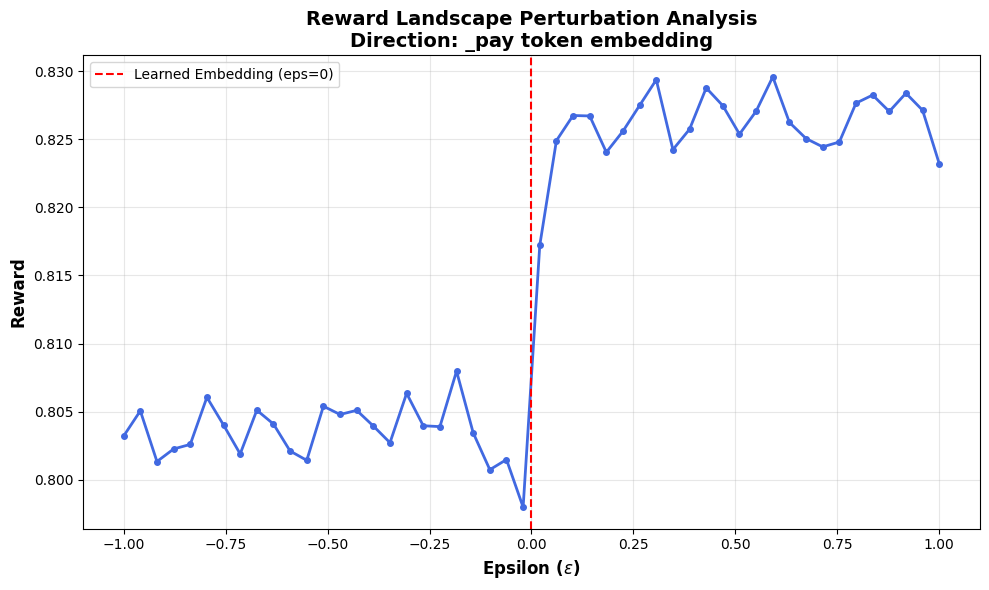

In [ ]:
"""
picking a random discrete reward hacked token
and sweeping embedding * epsilon where epsilon is in [-1, 1].
eps=1 means token is the original token and eps=0 means token has disappeared
"""
vocab_size = embed_layer.weight.shape[0]

#  Sweep Epsilon and Calculate Rewards
# --------------------------------------
epsilons = np.linspace(-1.0, 1.0, 50) # Sweep from -100% to +100% relative magnitude
rewards = []

print(f"Running perturbation analysis across {len(epsilons)} points...")

for eps in epsilons:
    # Construct full sequence
    full_embeddings = torch.cat([
        orig_embeddings, 
        torch.cat([best_discrete_tokens_embeddings[:, :random_discrete_token_index, :], best_discrete_tokens_embeddings[0, random_discrete_token_index, :] * eps, best_discrete_tokens_embeddings[:, random_discrete_token_index+1:, :]], dim=1),
        step_token_embeddings
    ], dim=1)
    
    # Forward Pass
    with torch.no_grad():
        base_output = model.pretrained_model(
            inputs_embeds=full_embeddings, 
            output_hidden_states=True
        )
        last_hidden_state = base_output.hidden_states[-1]
        reward_logits = model.v_head(last_hidden_state).squeeze(-1)
        reward = torch.sigmoid(reward_logits[0, -1]).item()
        
    rewards.append(reward)

# 4. Plot Results
# ---------------
plt.figure(figsize=(10, 6))
plt.plot(epsilons, rewards, marker='o', markersize=4, linewidth=2, color='royalblue')
plt.axvline(x=0, color='red', linestyle='--', label='Learned Embedding (eps=0)')
plt.xlabel(r'Epsilon ($\epsilon$)', fontsize=12, fontweight='bold')
plt.ylabel('Reward', fontsize=12, fontweight='bold')
plt.title(f'Reward Landscape Perturbation Analysis\nDirection: {tokenizer.decode(token_id)} token embedding', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Token 1: ' GPI' (ID: 96537, index: 51)
Token 2: ' fruit' (ID: 13779, index: 42)

Sweeping 25x25 = 625 points...


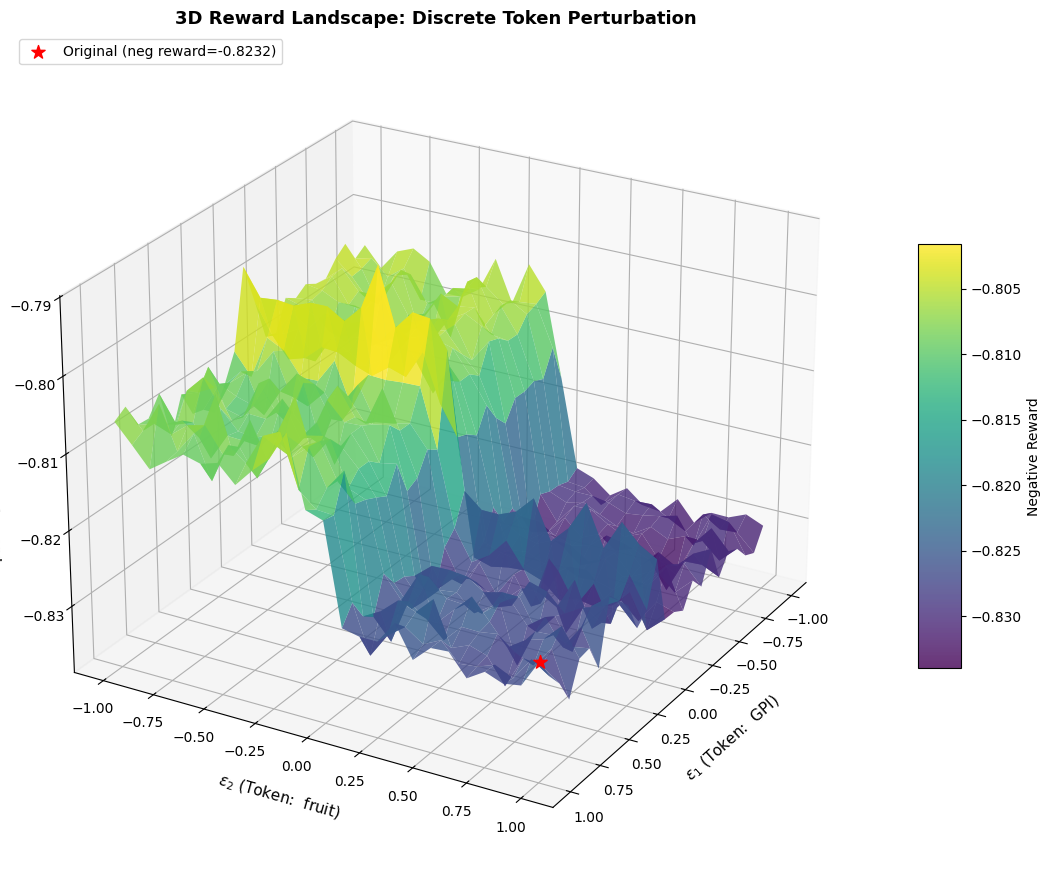


Neg reward range: [-0.8358, -0.7929]
Original neg reward (eps1=1, eps2=1): -0.8232


In [ ]:
"""
picking 2 random discrete reward hacked tokens
and sweeping embedding * epsilon where epsilon is in [-1, 1].
eps=1 means token is the original token and eps=0 means token has disappeared
"""
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load optimized tokens and setup
optimized_tokens = torch.load('optimized_100_tokens.pt')
optimized_steps = min_reward_steps.copy()

input_ids_orig, token_masks_orig = prepare_input(
    SKYWORK_MODEL_PATH, 
    problem=data["problem"], 
    steps=optimized_steps, 
    tokenizer=tokenizer,
    device=torch.device("cuda:0")
)
embed_layer = model.pretrained_model.get_input_embeddings()
orig_embeddings = embed_layer(input_ids_orig).unsqueeze(0)
step_token_embeddings = embed_layer(torch.tensor([198], device=torch.device("cuda:0"))).unsqueeze(0)
best_discrete_tokens_embeddings = embed_layer(torch.tensor(optimized_tokens, device="cuda:0")).unsqueeze(0)

# Pick two random token indices from the 100 optimized tokens
num_tokens = best_discrete_tokens_embeddings.shape[1]
random_indices = torch.randperm(num_tokens)[:2]
idx1, idx2 = random_indices[0].item(), random_indices[1].item()

token_id_1 = optimized_tokens[idx1]
token_id_2 = optimized_tokens[idx2]
token_str_1 = tokenizer.decode(token_id_1).replace('\n', '\\n')
token_str_2 = tokenizer.decode(token_id_2).replace('\n', '\\n')

print(f"Token 1: '{token_str_1}' (ID: {token_id_1}, index: {idx1})")
print(f"Token 2: '{token_str_2}' (ID: {token_id_2}, index: {idx2})")

# Grid parameters
n_points = 25
epsilons = np.linspace(-1.0, 1.0, n_points)
eps1_grid, eps2_grid = np.meshgrid(epsilons, epsilons)

rewards_grid = np.zeros((n_points, n_points))

print(f"\nSweeping {n_points}x{n_points} = {n_points**2} points...")

for i, eps1 in enumerate(epsilons):
    for j, eps2 in enumerate(epsilons):
        # Create modified embeddings by scaling the two selected tokens
        modified_embeddings = best_discrete_tokens_embeddings.clone()
        modified_embeddings[0, idx1, :] = modified_embeddings[0, idx1, :] * eps1
        modified_embeddings[0, idx2, :] = modified_embeddings[0, idx2, :] * eps2
        
        full_embeddings = torch.cat([
            orig_embeddings,
            modified_embeddings,
            step_token_embeddings
        ], dim=1)
        
        with torch.no_grad():
            base_output = model.pretrained_model(
                inputs_embeds=full_embeddings,
                output_hidden_states=True
            )
            reward_logits = model.v_head(base_output.hidden_states[-1]).squeeze(-1)
            reward = torch.sigmoid(reward_logits[0, -1]).item()
        
        rewards_grid[j, i] = -reward  # Negative reward

# Plot 3D surface
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    eps1_grid, eps2_grid, rewards_grid,
    cmap='viridis', edgecolor='none', alpha=0.8
)

# Mark the original point (eps1=1, eps2=1) - where embeddings are unmodified
one_idx = np.argmin(np.abs(epsilons - 1.0))
original_reward = rewards_grid[one_idx, one_idx]
ax.scatter([1], [1], [original_reward], color='red', s=100, marker='*',
           label=f'Original (neg reward={original_reward:.4f})', zorder=5)

ax.set_xlabel(f'$\\epsilon_1$ (Token: {token_str_1})', fontsize=11, labelpad=10)
ax.set_ylabel(f'$\\epsilon_2$ (Token: {token_str_2})', fontsize=11, labelpad=10)
ax.set_zlabel('Negative Reward', fontsize=11, labelpad=10)
ax.set_title('3D Reward Landscape: Discrete Token Perturbation', fontsize=13, fontweight='bold')

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Negative Reward')
ax.legend(loc='upper left')
ax.view_init(elev=25, azim=30)

plt.tight_layout()
plt.show()

print(f"\nNeg reward range: [{rewards_grid.min():.4f}, {rewards_grid.max():.4f}]")
print(f"Original neg reward (eps1=1, eps2=1): {original_reward:.4f}")

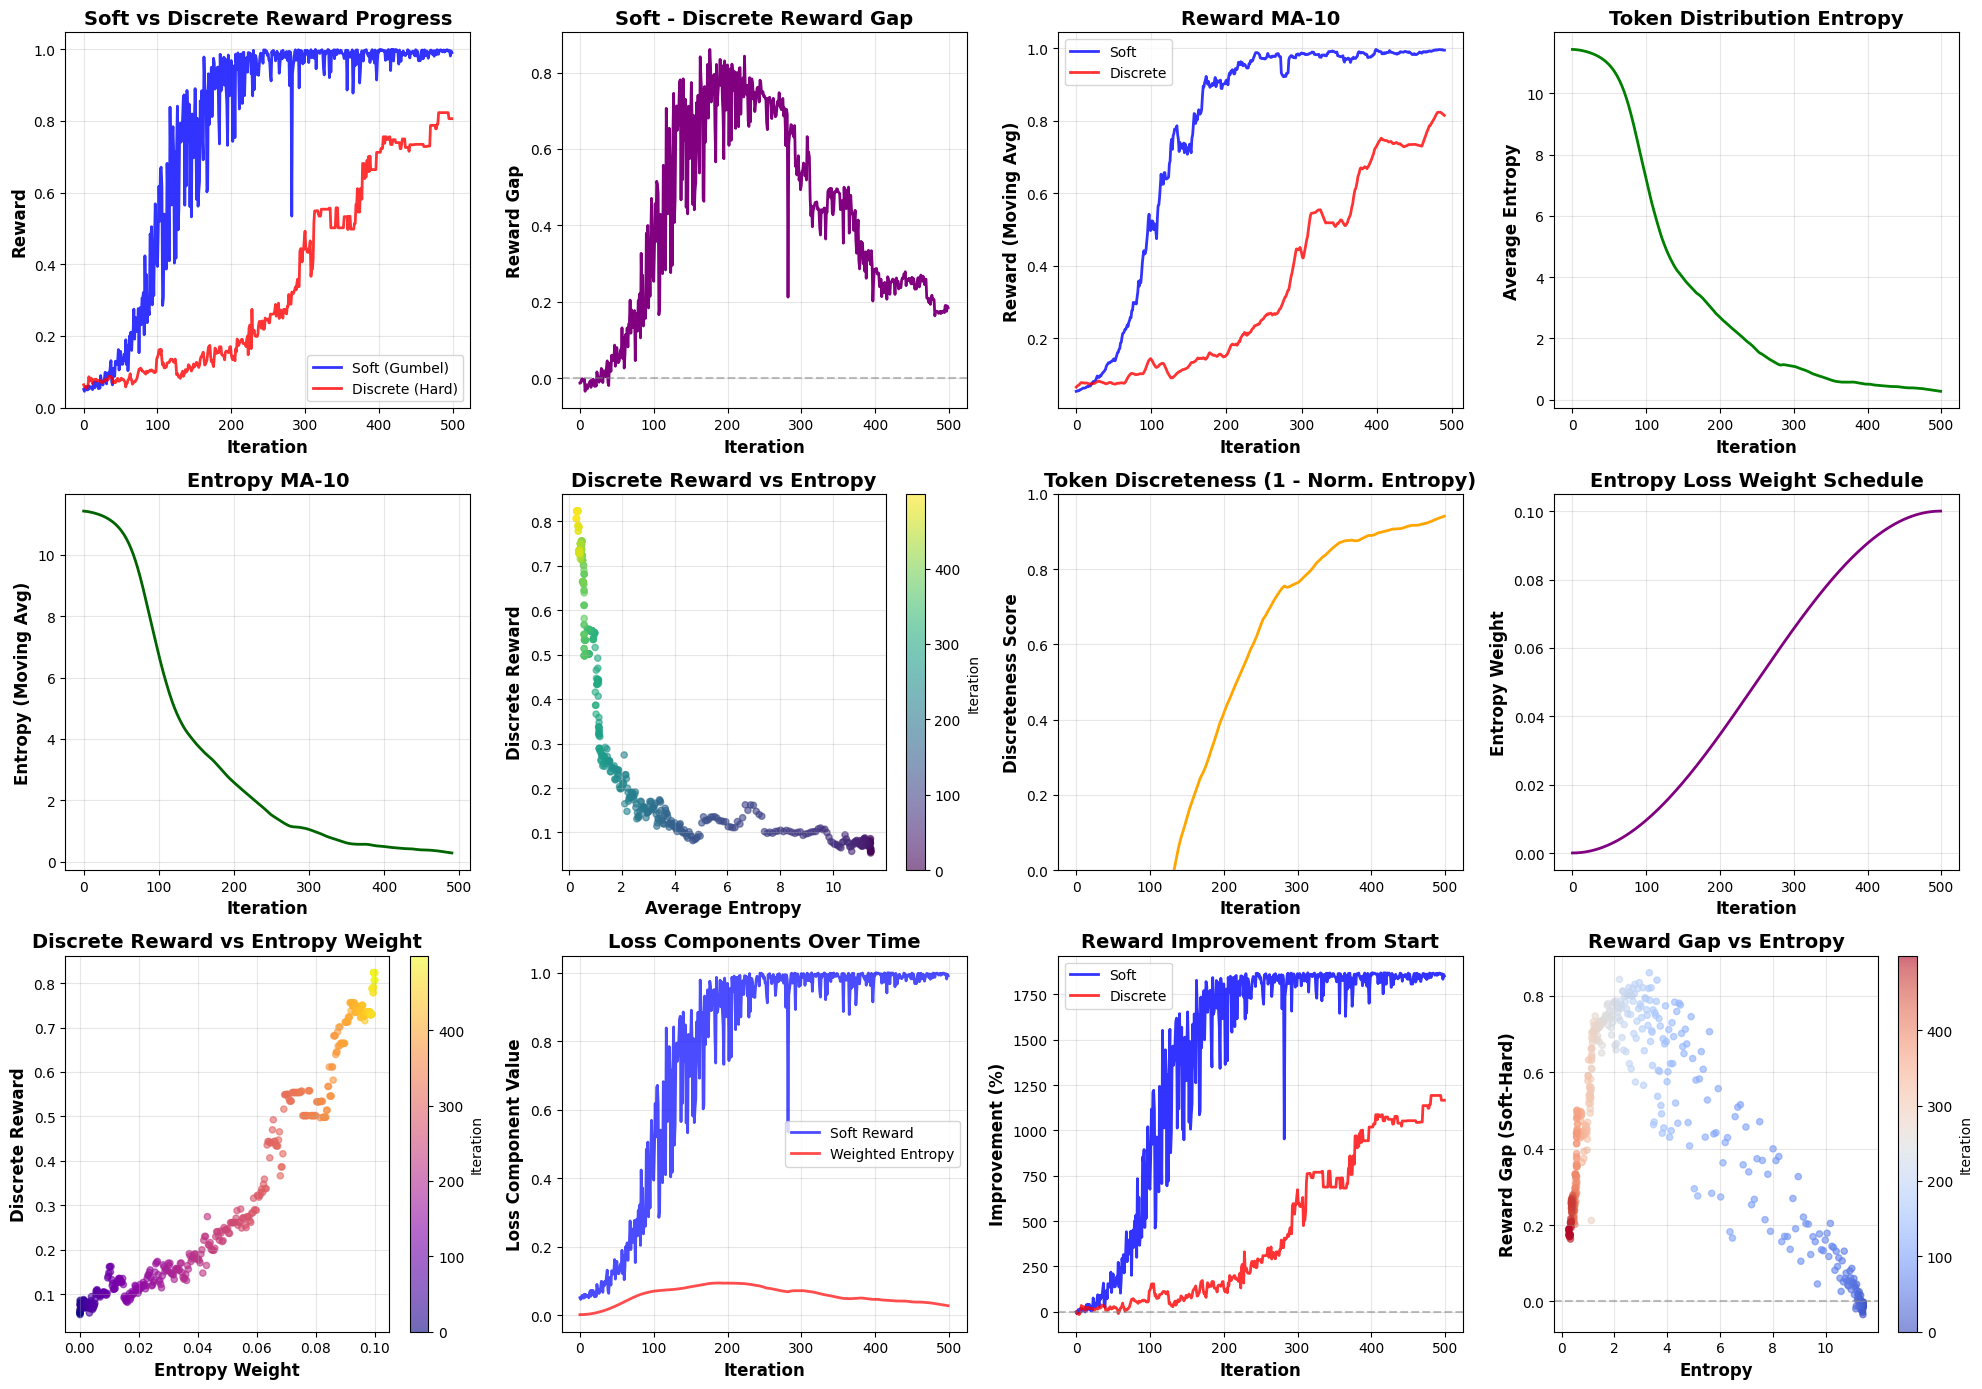


Optimization Summary:

Soft Reward Metrics (Gumbel-Softmax):
  Initial: 0.0508
  Final: 0.9908
  Best: 0.9996
  Improvement: 0.9489
  Improvement %: 1868.98%

Discrete Reward Metrics (Hard Tokens):
  Initial: 0.0637
  Final: 0.8064
  Best: 0.8232
  Improvement: 0.7595
  Improvement %: 1192.63%

Reward Gap Analysis (Soft - Discrete):
  Initial Gap: -0.0129
  Final Gap: +0.1844
  Average Gap: +0.4140
  Gap Change: +0.1973
  Max Gap: +0.8607 (iter 177)
  Min Gap: -0.0345 (iter 8)

Entropy Metrics:
  Initial Avg Entropy: 11.4309
  Final Avg Entropy: 0.2718
  Entropy Reduction: 11.1591
  Max Possible Entropy: 4.6052
  Final Discreteness: 94.10%

Entropy Weight Schedule:
  Initial Weight: 0.000100
  Final Weight: 0.100000
  Weight Increase: 0.099900
  Weight Multiplier: 1000.00x

Loss Component Analysis:
  Initial Weighted Entropy: 0.001143
  Final Weighted Entropy: 0.027180
  Despite 1000.0x weight increase, entropy decreased by 97.6%


In [25]:
# Plot the optimization progress
plt.figure(figsize=(20, 14))

# Plot 1: Soft vs Discrete Reward Comparison
plt.subplot(3, 4, 1)
plt.plot(reward_history, linewidth=2, color='blue', label='Soft (Gumbel)', alpha=0.8)
plt.plot(discrete_reward_history, linewidth=2, color='red', label='Discrete (Hard)', alpha=0.8)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Reward', fontsize=12, fontweight='bold')
plt.title('Soft vs Discrete Reward Progress', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Reward Gap (Soft - Discrete)
plt.subplot(3, 4, 2)
reward_gap = np.array(reward_history) - np.array(discrete_reward_history)
plt.plot(reward_gap, linewidth=2, color='purple')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Reward Gap', fontsize=12, fontweight='bold')
plt.title('Soft - Discrete Reward Gap', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 3: Reward moving average 
plt.subplot(3, 4, 3)
window_size = 10
if len(reward_history) >= window_size:
    soft_ma = np.convolve(reward_history, np.ones(window_size)/window_size, mode='valid')
    discrete_ma = np.convolve(discrete_reward_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(soft_ma, linewidth=2, color='blue', label='Soft', alpha=0.8)
    plt.plot(discrete_ma, linewidth=2, color='red', label='Discrete', alpha=0.8)
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Reward (Moving Avg)', fontsize=12, fontweight='bold')
    plt.title(f'Reward MA-{window_size}', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

# Plot 4: Entropy progress
plt.subplot(3, 4, 4)
plt.plot(entropy_history, linewidth=2, color='green')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Average Entropy', fontsize=12, fontweight='bold')
plt.title('Token Distribution Entropy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 5: Entropy moving average
plt.subplot(3, 4, 5)
if len(entropy_history) >= window_size:
    entropy_ma = np.convolve(entropy_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(entropy_ma, linewidth=2, color='darkgreen')
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Entropy (Moving Avg)', fontsize=12, fontweight='bold')
    plt.title(f'Entropy MA-{window_size}', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)

# Plot 6: Discrete Reward vs Entropy scatter
plt.subplot(3, 4, 6)
scatter = plt.scatter(entropy_history, discrete_reward_history, c=range(len(discrete_reward_history)), 
                     cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Iteration')
plt.xlabel('Average Entropy', fontsize=12, fontweight='bold')
plt.ylabel('Discrete Reward', fontsize=12, fontweight='bold')
plt.title('Discrete Reward vs Entropy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 7: Discreteness metric (inverse of normalized entropy)
plt.subplot(3, 4, 7)
# Normalize entropy by max possible (uniform distribution)
max_entropy = np.log(len(optimized_tokens))  # For discrete uniform distribution
normalized_entropy = np.array(entropy_history) / max_entropy
discreteness = 1 - normalized_entropy  # Higher = more discrete
plt.plot(discreteness, linewidth=2, color='orange')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Discreteness Score', fontsize=12, fontweight='bold')
plt.title('Token Discreteness (1 - Norm. Entropy)', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.grid(alpha=0.3)

# Plot 8: Entropy Weight Schedule
plt.subplot(3, 4, 8)
plt.plot(entropy_weight_history, linewidth=2, color='purple')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Entropy Weight', fontsize=12, fontweight='bold')
plt.title('Entropy Loss Weight Schedule', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 9: Entropy Weight vs Discrete Reward
plt.subplot(3, 4, 9)
scatter2 = plt.scatter(entropy_weight_history, discrete_reward_history, c=range(len(discrete_reward_history)),
                      cmap='plasma', alpha=0.6, s=20)
plt.colorbar(scatter2, label='Iteration')
plt.xlabel('Entropy Weight', fontsize=12, fontweight='bold')
plt.ylabel('Discrete Reward', fontsize=12, fontweight='bold')
plt.title('Discrete Reward vs Entropy Weight', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 10: Effective Loss Components Over Time
plt.subplot(3, 4, 10)
reward_component = np.array(reward_history)
entropy_component = np.array(entropy_history) * np.array(entropy_weight_history)
plt.plot(reward_component, linewidth=2, color='blue', label='Soft Reward', alpha=0.7)
plt.plot(entropy_component, linewidth=2, color='red', label='Weighted Entropy', alpha=0.7)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Loss Component Value', fontsize=12, fontweight='bold')
plt.title('Loss Components Over Time', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 11: Reward Improvement (relative to initial)
plt.subplot(3, 4, 11)
soft_improvement = (np.array(reward_history) - reward_history[0]) / max(abs(reward_history[0]), 1e-6) * 100
discrete_improvement = (np.array(discrete_reward_history) - discrete_reward_history[0]) / max(abs(discrete_reward_history[0]), 1e-6) * 100
plt.plot(soft_improvement, linewidth=2, color='blue', label='Soft', alpha=0.8)
plt.plot(discrete_improvement, linewidth=2, color='red', label='Discrete', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Improvement (%)', fontsize=12, fontweight='bold')
plt.title('Reward Improvement from Start', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 12: Correlation: Reward Gap vs Entropy
plt.subplot(3, 4, 12)
plt.scatter(entropy_history, reward_gap, c=range(len(reward_gap)), cmap='coolwarm', alpha=0.6, s=20)
plt.colorbar(label='Iteration')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Entropy', fontsize=12, fontweight='bold')
plt.ylabel('Reward Gap (Soft-Hard)', fontsize=12, fontweight='bold')
plt.title('Reward Gap vs Entropy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimization Summary:")
print(f"=" * 70)
print(f"\nSoft Reward Metrics (Gumbel-Softmax):")
print(f"  Initial: {reward_history[0]:.4f}")
print(f"  Final: {reward_history[-1]:.4f}")
print(f"  Best: {max(reward_history):.4f}")
print(f"  Improvement: {max(reward_history) - reward_history[0]:.4f}")
print(f"  Improvement %: {(max(reward_history) - reward_history[0]) / max(abs(reward_history[0]), 1e-6) * 100:.2f}%")

print(f"\nDiscrete Reward Metrics (Hard Tokens):")
print(f"  Initial: {discrete_reward_history[0]:.4f}")
print(f"  Final: {discrete_reward_history[-1]:.4f}")
print(f"  Best: {max(discrete_reward_history):.4f}")
print(f"  Improvement: {max(discrete_reward_history) - discrete_reward_history[0]:.4f}")
print(f"  Improvement %: {(max(discrete_reward_history) - discrete_reward_history[0]) / max(abs(discrete_reward_history[0]), 1e-6) * 100:.2f}%")

print(f"\nReward Gap Analysis (Soft - Discrete):")
initial_gap = reward_history[0] - discrete_reward_history[0]
final_gap = reward_history[-1] - discrete_reward_history[-1]
avg_gap = np.mean(reward_gap)
print(f"  Initial Gap: {initial_gap:+.4f}")
print(f"  Final Gap: {final_gap:+.4f}")
print(f"  Average Gap: {avg_gap:+.4f}")
print(f"  Gap Change: {final_gap - initial_gap:+.4f}")
print(f"  Max Gap: {max(reward_gap):+.4f} (iter {np.argmax(reward_gap)+1})")
print(f"  Min Gap: {min(reward_gap):+.4f} (iter {np.argmin(reward_gap)+1})")

print(f"\nEntropy Metrics:")
print(f"  Initial Avg Entropy: {entropy_history[0]:.4f}")
print(f"  Final Avg Entropy: {entropy_history[-1]:.4f}")
print(f"  Entropy Reduction: {entropy_history[0] - entropy_history[-1]:.4f}")
print(f"  Max Possible Entropy: {np.log(len(optimized_tokens)):.4f}")
print(f"  Final Discreteness: {(1 - entropy_history[-1]/np.log(len(optimized_tokens)))*100:.2f}%")

print(f"\nEntropy Weight Schedule:")
print(f"  Initial Weight: {entropy_weight_history[0]:.6f}")
print(f"  Final Weight: {entropy_weight_history[-1]:.6f}")
print(f"  Weight Increase: {entropy_weight_history[-1] - entropy_weight_history[0]:.6f}")
print(f"  Weight Multiplier: {entropy_weight_history[-1] / max(entropy_weight_history[0], 1e-9):.2f}x")

print(f"\nLoss Component Analysis:")
print(f"  Initial Weighted Entropy: {entropy_history[0] * entropy_weight_history[0]:.6f}")
print(f"  Final Weighted Entropy: {entropy_history[-1] * entropy_weight_history[-1]:.6f}")
print(f"  Despite {entropy_weight_history[-1]/entropy_weight_history[0]:.1f}x weight increase, entropy decreased by {(1-entropy_history[-1]/entropy_history[0])*100:.1f}%")


# Getting Reward with Continuous Token

In [ ]:
# Save and load the best_continous_token
# best_continuous_tokens = torch.tensor(best_continuous_tokens, device="cuda:0", dtype=torch.bfloat16)
# torch.save(best_continuous_tokens, 'best_continuous_tokens.pt')
best_continuous_tokens = torch.load('best_continuous_tokens.pt')

tensor([4.1633e-15, 1.0214e-13, 2.0761e-14,  ..., 2.1788e-15, 1.0769e-14,
        1.3711e-14], device='cuda:0', dtype=torch.bfloat16)

In [19]:
optimized_steps = min_reward_steps.copy()
# optimized_steps[-1] = optimized_steps[-1] +'\n' +optimized_text
input_ids_orig, token_masks_orig = prepare_input(
        SKYWORK_MODEL_PATH, 
        problem=data["problem"], 
        steps=optimized_steps, 
        tokenizer=tokenizer,
        device=torch.device("cuda:0")
    )
embed_layer = model.pretrained_model.get_input_embeddings()
orig_embeddings = embed_layer(input_ids_orig).unsqueeze(0)
step_token_embeddings = embed_layer(torch.tensor([198],device=torch.device("cuda:0"))).unsqueeze(0)
best_continuous_tokens_embeddings = (torch.tensor(best_continuous_tokens, device="cuda:0", dtype=torch.bfloat16)@embed_layer.weight).unsqueeze(0)
full_embeddings = torch.cat([orig_embeddings, best_continuous_tokens_embeddings,step_token_embeddings, ], dim=1)


base_output = model.pretrained_model(
                    inputs_embeds=full_embeddings, 
                    output_hidden_states=True
                )
last_hidden_state = base_output.hidden_states[-1]
# Pass through value head to get reward logits
reward_logits = model.v_head(last_hidden_state).squeeze(-1)
# Get the reward for the last token
reward_proxy = torch.sigmoid(reward_logits[0, -1])
print(reward_proxy)

tensor(0.8626, device='cuda:0', grad_fn=<SigmoidBackward0>)


In [20]:
best_continuous_tokens_embeddings[0]

tensor([[-0.0082,  0.0063, -0.0032,  ..., -0.0027, -0.0005,  0.0134]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<SelectBackward0>)

Analyzing sharpness for 6 tokens...


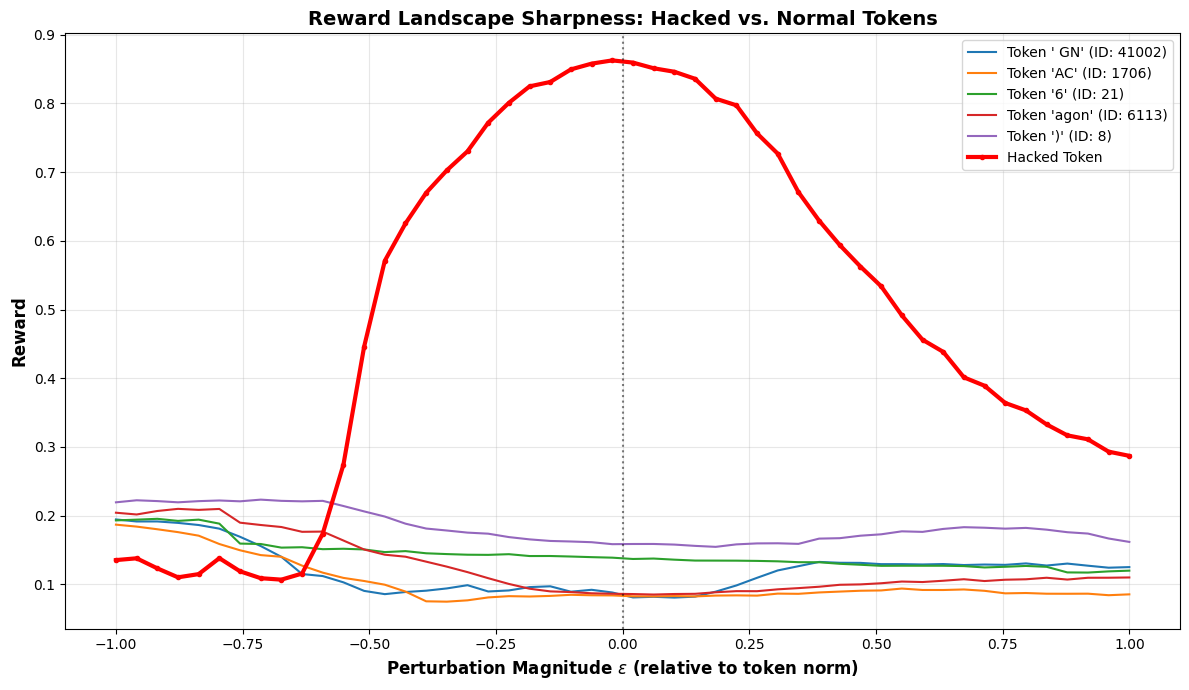

In [83]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Common Inputs
# ----------------------
optimized_steps = min_reward_steps.copy()
input_ids_orig, token_masks_orig = prepare_input(
    SKYWORK_MODEL_PATH, 
    problem=data["problem"], 
    steps=optimized_steps, 
    tokenizer=tokenizer,
    device=torch.device("cuda:0")
)
embed_layer = model.pretrained_model.get_input_embeddings()
orig_embeddings = embed_layer(input_ids_orig).unsqueeze(0)
step_token_embeddings = embed_layer(torch.tensor([198], device=torch.device("cuda:0"))).unsqueeze(0)

# 2. Define Tokens to Analyze
# ---------------------------
# (A) The Hacked Token
coeffs = torch.tensor(best_continuous_tokens, device="cuda:0", dtype=torch.bfloat16)
v_hacked = (coeffs @ embed_layer.weight).detach()
hacked_token_info = {"name": "Hacked Token", "embedding": v_hacked, "color": "red", "linewidth": 3}

# (B) Random "Normal" Tokens
num_random_tokens = 5
vocab_size = embed_layer.weight.shape[0]
idx = torch.randint(low=0, high=input_ids_orig.size(0), size=(num_random_tokens,))
random_token_ids = input_ids_orig[idx]
tokens_to_analyze = [hacked_token_info]

for tid in random_token_ids:
    token_str = tokenizer.decode([tid.item()])
    # Escape special characters for plot label
    clean_str = token_str.replace('\n', '\\n').replace(' ', ' ')
    tokens_to_analyze.append({
        "name": f"Token '{clean_str}' (ID: {tid.item()})",
        "embedding": embed_layer(tid).detach(),
        "color": None, # Will be assigned automatically
        "linewidth": 1.5
    })

# 3. Define Common Perturbation Direction
# ---------------------------------------
# Use ONE consistent random direction type for fairness, 
# but scaled to each token's norm individually.
random_weights = torch.rand(vocab_size, device="cuda:0", dtype=torch.float32)
random_weights = random_weights / random_weights.sum()
random_weights = random_weights.to(torch.bfloat16)
d_raw = (random_weights @ embed_layer.weight).detach()
d_raw_norm = torch.norm(d_raw)
d_unit = d_raw / d_raw_norm  # Base unit vector direction

# 4. Sweep and Collect Data
# -------------------------
epsilons = np.linspace(-1.0, 1.0, 50)
results = {}

print(f"Analyzing sharpness for {len(tokens_to_analyze)} tokens...")

for token_info in tokens_to_analyze:
    v_curr = token_info["embedding"]
    v_norm = torch.norm(v_curr)
    
    # Scale perturbation to this specific token's norm
    # This ensures epsilon=0.1 means "10% perturbation" for EVERY token
    d_scaled = d_unit * v_norm
    
    rewards = []
    for eps in epsilons:
        perturbation = eps * d_scaled
        v_perturbed = v_curr + perturbation
        
        # Prepare full embedding sequence
        v_perturbed_reshaped = v_perturbed.view(1, 1, -1)
        full_embeddings = torch.cat([
            orig_embeddings, 
            v_perturbed_reshaped, 
            step_token_embeddings
        ], dim=1)
        
        with torch.no_grad():
            base_output = model.pretrained_model(
                inputs_embeds=full_embeddings, 
                output_hidden_states=True
            )
            reward_logits = model.v_head(base_output.hidden_states[-1]).squeeze(-1)
            reward = torch.sigmoid(reward_logits[0, -1]).item()
        rewards.append(reward)
    
    results[token_info["name"]] = rewards

# 5. Plot Comparison
# ------------------
plt.figure(figsize=(12, 7))

# Plot normal tokens first (in background)
for i, token_info in enumerate(tokens_to_analyze[1:]):
    name = token_info["name"]
    plt.plot(epsilons, results[name], 
             linewidth=token_info["linewidth"], 
             label=name)

# Plot hacked token last (on top)
hacked_name = tokens_to_analyze[0]["name"]
plt.plot(epsilons, results[hacked_name], 
         color=tokens_to_analyze[0]["color"], 
         linewidth=tokens_to_analyze[0]["linewidth"], 
         label=hacked_name,
         marker='o', markersize=3)

plt.axvline(x=0, color='black', linestyle=':', alpha=0.5)
plt.xlabel(r'Perturbation Magnitude $\epsilon$ (relative to token norm)', fontsize=12, fontweight='bold')
plt.ylabel('Reward', fontsize=12, fontweight='bold')
plt.title('Reward Landscape Sharpness: Hacked vs. Normal Tokens', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Direction orthogonality check (should be ~0): 0.376542

Analyzing 3D reward landscape for 6 tokens...
Grid: 25x25 = 625 evaluations per token

Processing 1/6: Hacked Token


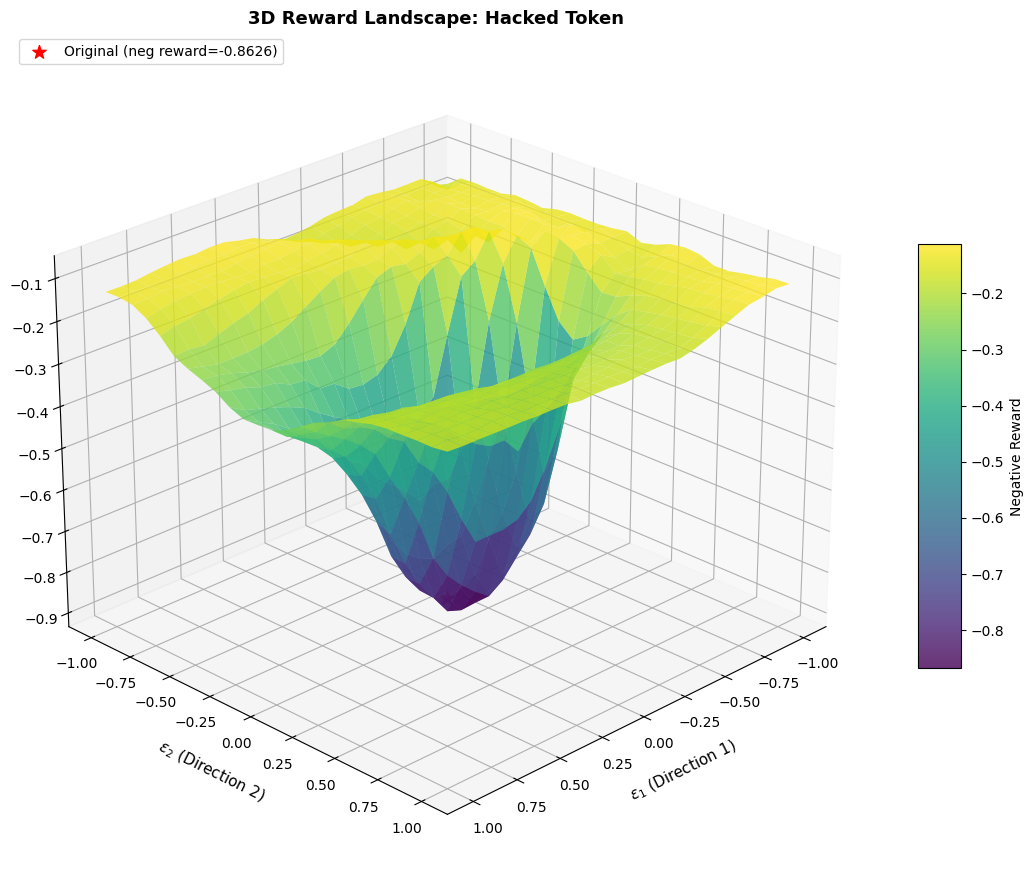

  Neg reward range: [-0.8774, -0.1037]
  Center neg reward: -0.8626

Processing 2/6: Token ',F' (ID: 27229)


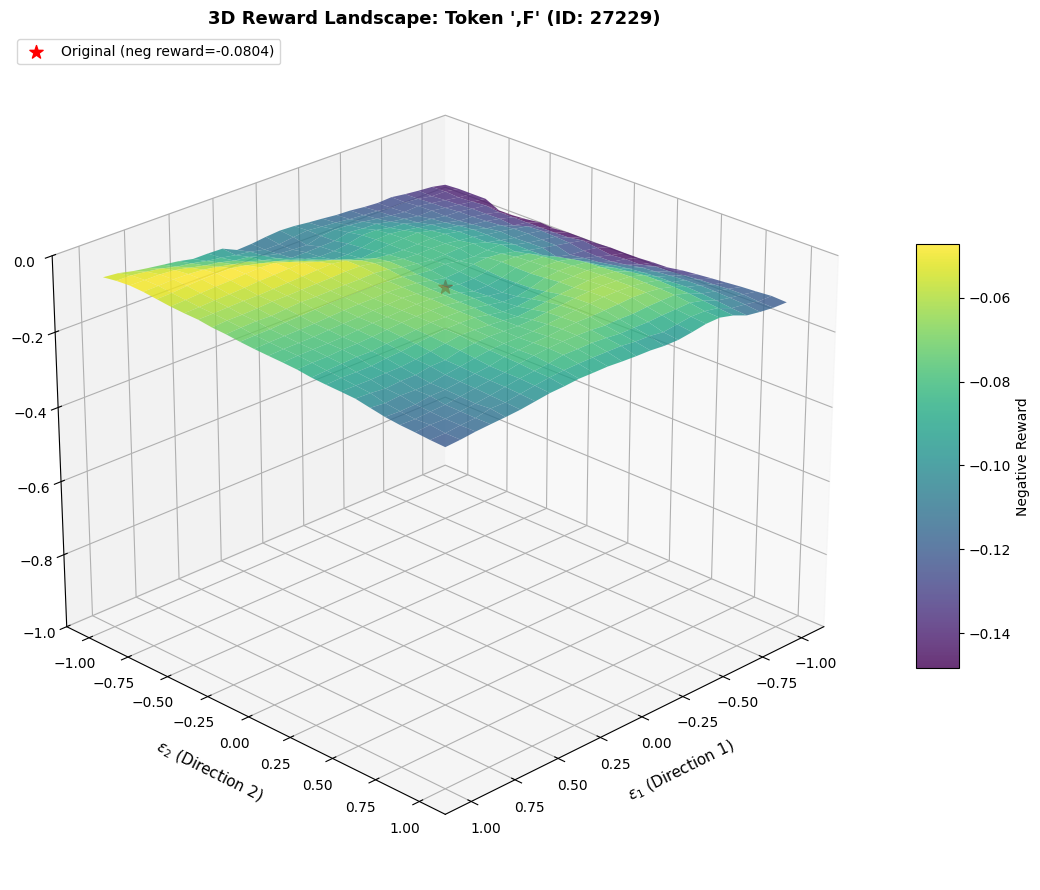

  Neg reward range: [-0.1607, -0.0449]
  Center neg reward: -0.0804

Processing 3/6: Token ' the' (ID: 279)


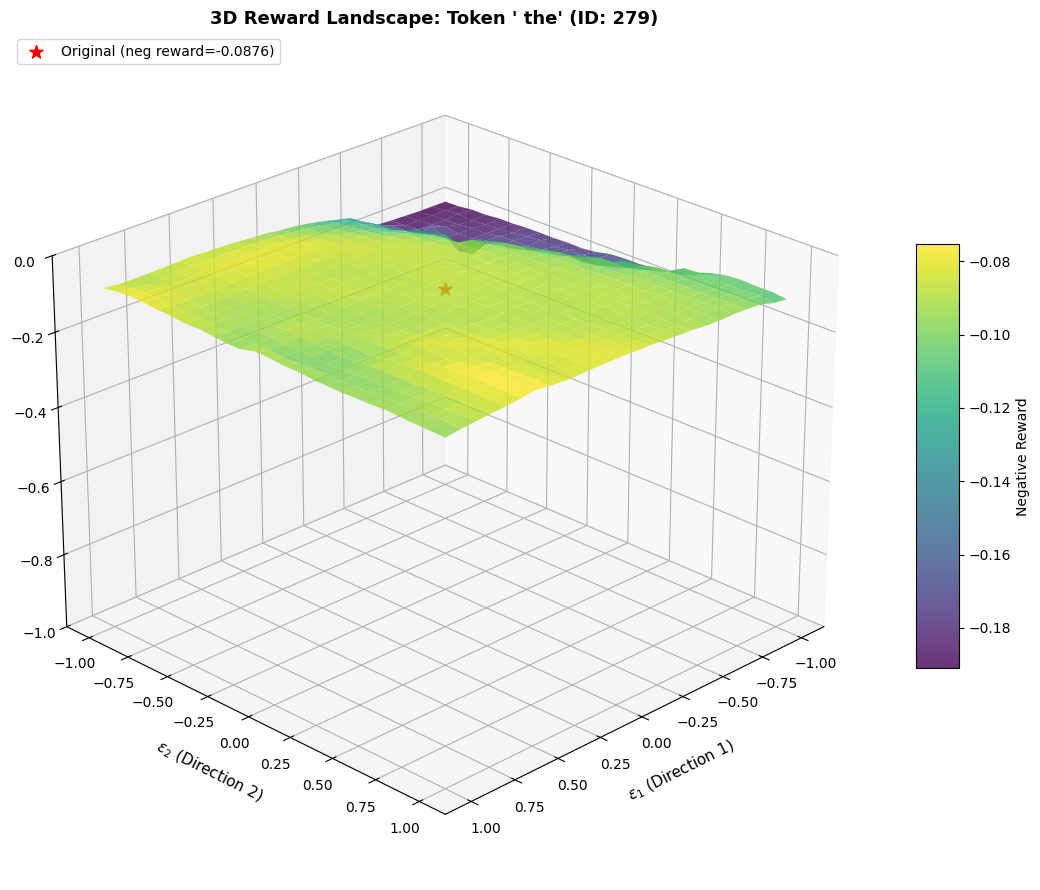

  Neg reward range: [-0.1922, -0.0732]
  Center neg reward: -0.0876

Processing 4/6: Token ' same' (ID: 1852)


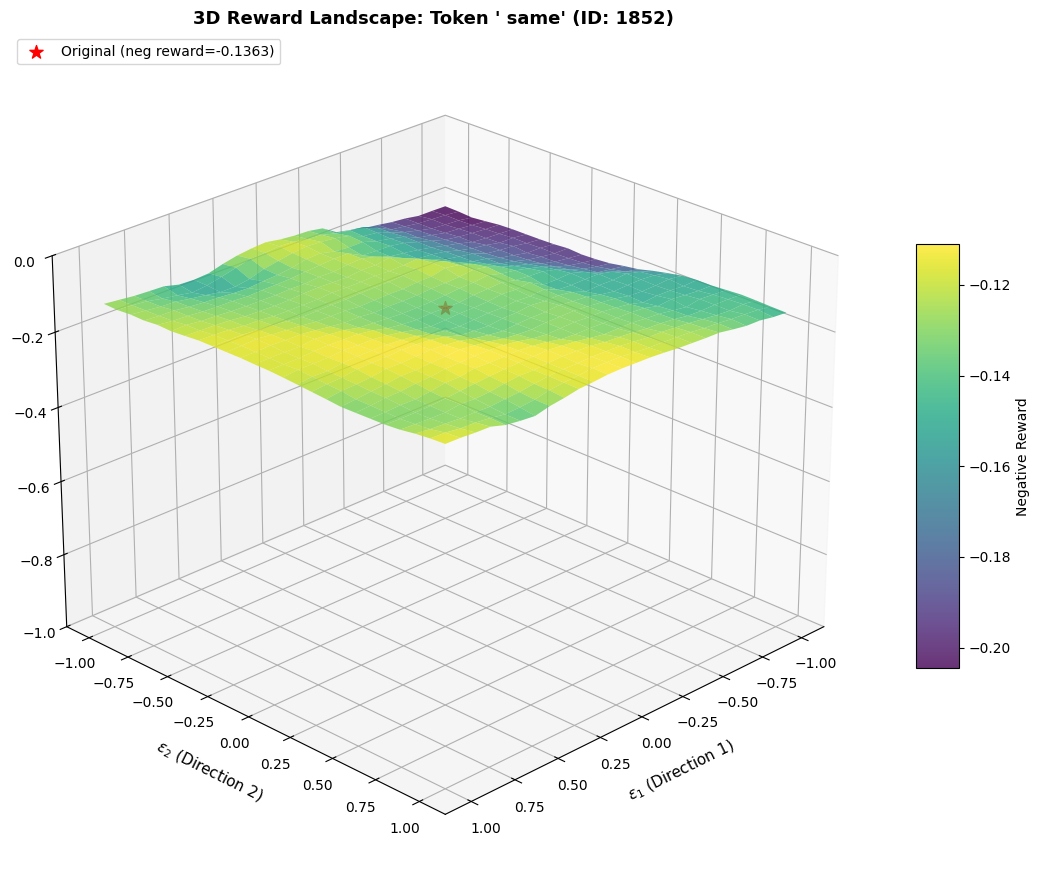

  Neg reward range: [-0.2084, -0.1094]
  Center neg reward: -0.1363

Processing 5/6: Token ' units' (ID: 8153)


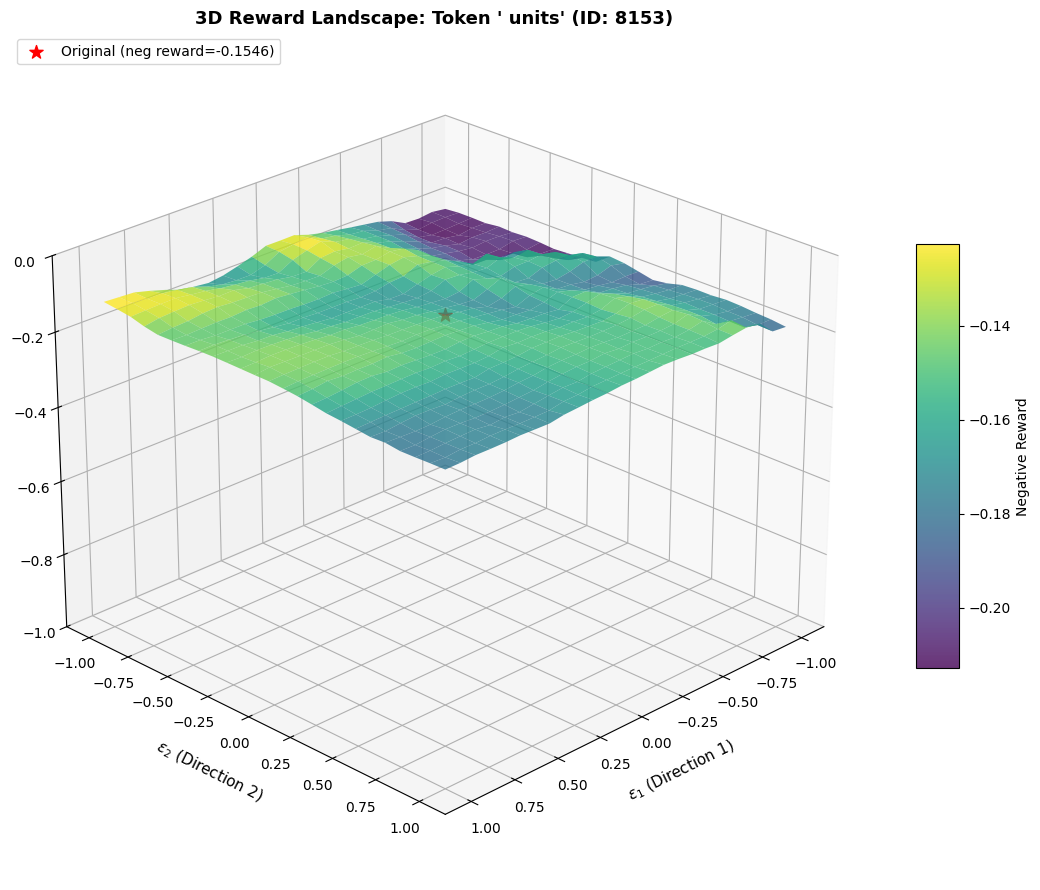

  Neg reward range: [-0.2153, -0.1183]
  Center neg reward: -0.1546

Processing 6/6: Token 'Area' (ID: 8726)


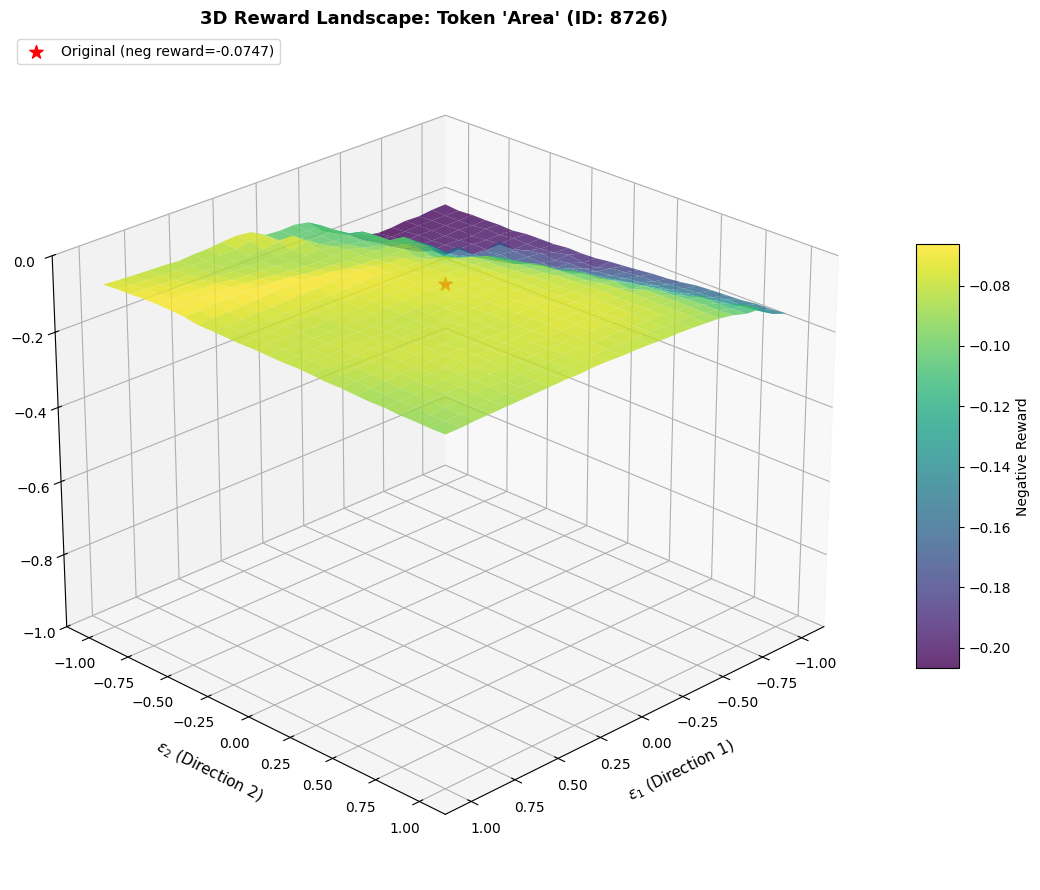

  Neg reward range: [-0.2091, -0.0638]
  Center neg reward: -0.0747



In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Setup Common Inputs
# ----------------------
optimized_steps = min_reward_steps.copy()
input_ids_orig, token_masks_orig = prepare_input(
    SKYWORK_MODEL_PATH, 
    problem=data["problem"], 
    steps=optimized_steps, 
    tokenizer=tokenizer,
    device=torch.device("cuda:0")
)
embed_layer = model.pretrained_model.get_input_embeddings()
orig_embeddings = embed_layer(input_ids_orig).unsqueeze(0)
step_token_embeddings = embed_layer(torch.tensor([198], device=torch.device("cuda:0"))).unsqueeze(0)

# 2. Define Tokens to Analyze
# ---------------------------
# (A) The Hacked Token
coeffs = torch.tensor(best_continuous_tokens, device="cuda:0", dtype=torch.bfloat16)
v_hacked = (coeffs @ embed_layer.weight).detach()
hacked_token_info = {"name": "Hacked Token", "embedding": v_hacked}

# (B) Random "Normal" Tokens
num_random_tokens = 5
vocab_size = embed_layer.weight.shape[0]
idx = torch.randint(low=0, high=input_ids_orig.size(0), size=(num_random_tokens,))
random_token_ids = input_ids_orig[idx]
tokens_to_analyze = [hacked_token_info]

for tid in random_token_ids:
    token_str = tokenizer.decode([tid.item()])
    clean_str = token_str.replace('\n', '\\n').replace(' ', ' ')
    tokens_to_analyze.append({
        "name": f"Token '{clean_str}' (ID: {tid.item()})",
        "embedding": embed_layer(tid).detach(),
    })

# 3. Define Two Random Perturbation Directions (Orthogonalized)
# -------------------------------------------------------------
# Direction 1
random_weights_1 = torch.rand(vocab_size, device="cuda:0", dtype=torch.float32)
random_weights_1 = random_weights_1 / random_weights_1.sum()
random_weights_1 = random_weights_1.to(torch.bfloat16)
d1_raw = (random_weights_1 @ embed_layer.weight).detach()
d1_unit = d1_raw / torch.norm(d1_raw)

# Direction 2 - orthogonalize via Gram-Schmidt
random_weights_2 = torch.rand(vocab_size, device="cuda:0", dtype=torch.float32)
random_weights_2 = random_weights_2 / random_weights_2.sum()
random_weights_2 = random_weights_2.to(torch.bfloat16)
d2_raw = (random_weights_2 @ embed_layer.weight).detach()
d2_raw = d2_raw - (torch.dot(d2_raw.float(), d1_unit.float()) * d1_unit.float()).to(torch.bfloat16)
d2_unit = d2_raw / torch.norm(d2_raw)

print(f"Direction orthogonality check (should be ~0): {torch.dot(d1_unit.float(), d2_unit.float()).item():.6f}")

# 4. Sweep and Create Individual 3D Plots
# ---------------------------------------
n_points = 25  # Grid resolution
epsilons = np.linspace(-1.0, 1.0, n_points)
eps1_grid, eps2_grid = np.meshgrid(epsilons, epsilons)

print(f"\nAnalyzing 3D reward landscape for {len(tokens_to_analyze)} tokens...")
print(f"Grid: {n_points}x{n_points} = {n_points**2} evaluations per token\n")

for token_idx, token_info in enumerate(tokens_to_analyze):
    v_curr = token_info["embedding"]
    v_norm = torch.norm(v_curr)
    
    d1_scaled = d1_unit * v_norm
    d2_scaled = d2_unit * v_norm
    
    rewards_grid = np.zeros((n_points, n_points))
    
    print(f"Processing {token_idx + 1}/{len(tokens_to_analyze)}: {token_info['name']}")
    
    for i, eps1 in enumerate(epsilons):
        for j, eps2 in enumerate(epsilons):
            perturbation = eps1 * d1_scaled + eps2 * d2_scaled
            v_perturbed = v_curr + perturbation
            
            v_perturbed_reshaped = v_perturbed.view(1, 1, -1)
            full_embeddings = torch.cat([
                orig_embeddings, 
                v_perturbed_reshaped, 
                step_token_embeddings
            ], dim=1)
            
            with torch.no_grad():
                base_output = model.pretrained_model(
                    inputs_embeds=full_embeddings, 
                    output_hidden_states=True
                )
                reward_logits = model.v_head(base_output.hidden_states[-1]).squeeze(-1)
                reward = torch.sigmoid(reward_logits[0, -1]).item()
            
            rewards_grid[j, i] = -reward  # Store negative reward
    
    # Create 3D Surface Plot
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(
        eps1_grid, eps2_grid, rewards_grid,
        cmap='viridis', edgecolor='none', alpha=0.8
    )
    
    center_idx = n_points // 2
    center_reward = rewards_grid[center_idx, center_idx]
    ax.scatter([0], [0], [center_reward], color='red', s=100, marker='*', 
               label=f'Original (neg reward={center_reward:.4f})', zorder=5)
    
    ax.set_xlabel(r'$\epsilon_1$ (Direction 1)', fontsize=11, labelpad=10)
    ax.set_ylabel(r'$\epsilon_2$ (Direction 2)', fontsize=11, labelpad=10)
    ax.set_zlabel('Negative Reward', fontsize=11, labelpad=10)
    ax.set_title(f'3D Reward Landscape: {token_info["name"]}', fontsize=13, fontweight='bold')
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Negative Reward')
    ax.legend(loc='upper left')
    ax.view_init(elev=25, azim=45)
    
    # Fix z-axis range for non-hacked tokens
    if token_idx > 0:
        ax.set_zlim(-1.0, 0.0)
    
    plt.tight_layout()
    plt.show()
    
    print(f"  Neg reward range: [{rewards_grid.min():.4f}, {rewards_grid.max():.4f}]")
    print(f"  Center neg reward: {center_reward:.4f}\n")